# Metabolomics DSP Course - Data Analysis

In this demonstrative exercise, we will perform the downstream analysis of the
Metabolights dataset MTBLS8735. This dataset contains three control samples derived from
healthy samples, three samples from patients with Cardiovascular disease and four pooled
Quality Control (QC) samples.

The rough workflow of this analysis is:
- Data filtering
- Imputation
- Correcting instrumental drift
- Normalisation and Visualisation
- Statistical analysis (ANCOVA)

For most of the analyses, we will be using the python package ACORE, which is a package
developed by the Data Science Platform of NNF BRIGHT for analysing multi-omics molecular
data - including metabolomics data. The documentation of this package can be found here:
[`acore documentation`](https://analytics-core.readthedocs.io/latest/). Go there to read
about the functions in more detail, or to find out what else you can analyse with acore.

Although we are using acore for almost everything, all of these analyses can be carried
out with other programs or in your own code, created in R, Python or other places, as
well. This notebook serves primarily as a demonstration of the necessary steps of a
typical downstream metabolomics data analysis.

## Imports

In [1]:
%pip install acore

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import numpy as np
import pandas as pd
import vuecore.plots.basic.scatter
from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Helper functions
First, we are defining some helper functions. Feel free to ignore these while we go
through the exercise, they are for example plotting functions. Do, however, run the
cells.

In [3]:
def plot_pca(
    df: pd.DataFrame,
    groups: dict[str, list],  # e.g. {"Control": [0,1,2], "Treatment": [3,4,5]}
    scale: bool = True,
    n_components: int = 2,
    figsize: tuple = (7, 5),
    title: str = "PCA Score Plot",
    palette: list = None,
    ellipse: bool = True,  # 95% confidence ellipse per group
    label_points: bool = False,  # annotate each point with its index
):
    """
    PCA score plot for metabolomics data.

    Parameters
    ----------
    df          : samples × features DataFrame (rows = samples)
    groups      : dict mapping group name -> list of row indices (int or label)
    scale       : z-score scale features before PCA (recommended)
    n_components: number of PCs to compute (≥2)
    ellipse     : draw a 95% confidence ellipse per group
    label_points: annotate each dot with its row index/label
    """

    # build ordered index and group label array
    all_idx = [i for idxs in groups.values() for i in idxs]
    group_labels = {i: grp for grp, idxs in groups.items() for i in idxs}

    X = df.loc[all_idx].copy()
    labels = [group_labels[i] for i in X.index]

    # scale & fit PCA
    if scale:
        X_vals = StandardScaler().fit_transform(X.values)
    else:
        X_vals = X.values

    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(X_vals)
    var_exp = pca.explained_variance_ratio_ * 100

    # colours
    group_names = list(groups.keys())
    if palette is None:
        palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    color_map = {g: palette[i % len(palette)] for i, g in enumerate(group_names)}

    # plot
    fig, ax = plt.subplots(figsize=figsize)

    for grp in group_names:
        mask = [l == grp for l in labels]
        pts = scores[mask]
        color = color_map[grp]

        ax.scatter(pts[:, 0], pts[:, 1], label=grp, color=color, s=80, zorder=3)

        if label_points:
            idx_list = groups[grp]
            for pt, idx in zip(pts, idx_list):
                ax.annotate(
                    str(idx), pt, textcoords="offset points", xytext=(5, 4), fontsize=8
                )

        if ellipse and len(pts) > 2:
            _confidence_ellipse(pts[:, 0], pts[:, 1], ax, color=color)

    ax.axhline(0, color="grey", lw=0.5, ls="--")
    ax.axvline(0, color="grey", lw=0.5, ls="--")
    ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)", fontsize=12)
    ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(framealpha=0.3)
    plt.tight_layout()
    plt.show()

    return pca, scores, var_exp


def _confidence_ellipse(x, y, ax, n_std=1.96, color="tab:blue", alpha=0.15, **kwargs):
    """Draw a covariance-based 95% confidence ellipse."""

    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx = np.sqrt(1 + pearson)
    ry = np.sqrt(1 - pearson)

    ellipse = Ellipse(
        (0, 0),
        width=rx * 2,
        height=ry * 2,
        facecolor=color,
        alpha=alpha,
        edgecolor=color,
        linewidth=1.5,
        linestyle="--",
        **kwargs,
    )
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x, mean_y = np.mean(x), np.mean(y)

    t = (
        transforms.Affine2D()
        .rotate_deg(45)
        .scale(scale_x, scale_y)
        .translate(mean_x, mean_y)
    )

    ellipse.set_transform(t + ax.transData)
    ax.add_patch(ellipse)


def plot_feature_missingness(data):
    missing_features = data.isnull().mean() * 100
    missing_features_nonzero = missing_features[missing_features > 0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    ax = axes[0]
    ax.hist(
        missing_features_nonzero.values,
        bins=30,
        color="mediumvioletred",
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_xlabel("Missing (%)")
    ax.set_ylabel("Number of features")
    ax.set_title(
        f"Distribution of missingness\n({len(missing_features_nonzero)} features with any missing)"
    )
    ax.axvline(
        x=20, color="black", linestyle="--", linewidth=0.8, label="20% threshold"
    )
    ax.legend()

    # Dot plot, sorted by missingness
    ax = axes[1]
    sorted_missing = missing_features.sort_values(ascending=True).reset_index(drop=True)
    ax.scatter(
        sorted_missing.index,
        sorted_missing.values,
        s=4,
        color="mediumvioletred",
        alpha=0.6,
        linewidths=0,
    )
    ax.set_xlabel("Features (sorted by missingness)")
    ax.set_ylabel("Missing (%)")
    ax.set_title("Sorted missingness per feature")
    ax.axhline(
        y=20, color="black", linestyle="--", linewidth=0.8, label="20% threshold"
    )
    ax.legend()

    plt.tight_layout()
    plt.show()


def missingness_summary(df_before, df_after):
    total = df_before.size
    n_before = df_before.isnull().sum().sum()
    n_after = df_after.isnull().sum().sum()

    print(f"Total values      : {total:,}")
    print(f"Missing before    : {n_before:,}  ({100*n_before/total:.1f}%)")
    print(f"Missing after     : {n_after:,}  ({100*n_after/total:.1f}%)")
    print(
        f"Features affected : {(df_before.isnull().any()).sum()} / {df_before.shape[1]}"
    )
    print(
        f"Samples affected  : {(df_before.isnull().any(axis=1)).sum()} / {df_before.shape[0]}"
    )


def plot_intensity_distribution(data):
    values = data.values.flatten().astype(float)

    n_total = data.size
    n_missing = int(np.isnan(values).sum())
    pct_missing = n_missing / n_total * 100

    log_values = np.log10(values[(~np.isnan(values)) & (values > 0)])

    fig, (ax_nan, ax_hist) = plt.subplots(
        1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [1, 8]}, sharey=True
    )

    ax_nan.bar(0, n_missing, width=0.2, color="mediumvioletred", alpha=0.8)
    ax_nan.set_xlim(-0.5, 0.5)
    ax_nan.set_xticks([0])
    ax_nan.set_xticklabels([f"NaN\n({pct_missing:.1f}%)"], fontsize=9)
    ax_nan.set_ylabel("Count")

    ax_hist.hist(
        log_values, bins=100, color="cornflowerblue", edgecolor="none", alpha=0.8
    )
    ax_hist.set_xlabel("Intensity (log₁₀)")
    ax_hist.set_title("Intensity distribution (all features, all samples)")
    ax_hist.yaxis.set_visible(False)

    plt.tight_layout()
    plt.show()


def plot_loess_example_curve(
    df: pd.DataFrame,
    feature_idx: int,
    samples: list,
    qcs: list,
    sample_order: pd.DataFrame,
    show_corrected: bool = True,
    alpha: float = None,  # fixed smoothing span; if None, selected by LOOCV
):
    """
    Plot the raw intensities, LOESS drift curve, and optionally the corrected
    intensities for a single feature according to the loess drift correction function.
    Useful for inspecting drift behaviour before running full drift correction.

    The drift curve is estimated with the same method used by
    ldc.run_drift_correction: LOESS is fit to the QC points and then
    interpolated across all injection positions via a cubic spline
    (qc_rlsc_loess).

    Parameters
    ----------
    df : pd.DataFrame
        Feature matrix with samples as rows and features as columns.
        Metadata columns should have been removed already.
    feature_idx : int
        Column index of the feature to plot.
    samples : list of str
        Row index labels of the biological samples.
    qcs : list of str
        Row index labels of the pooled QC samples.
    sample_order : pd.DataFrame
        Injection-order table with columns `File Name` and `Sample ID`
        (integer run order).
    show_corrected : bool, optional
        If True (default), overlays drift-corrected sample intensities as
        diamond markers.
    alpha : float, optional
        LOESS smoothing span (0 < α ≤ 1). If None (default), the optimal span
        is selected automatically by leave-one-out cross-validation over
        α ∈ [0.40, 1.00]. The selected value is shown in the legend.
    """

    all_rows = samples + qcs
    feature_col = df.iloc[:, feature_idx]

    order_dict = sample_order.set_index("File Name")["Sample ID"].to_dict()
    x_all = np.array([order_dict.get(r, np.nan) for r in all_rows])
    y_all = feature_col.loc[all_rows].astype(float).values

    n_s = len(samples)
    x_sample, y_sample = x_all[:n_s], y_all[:n_s]
    x_qc_arr, y_qc_arr = x_all[n_s:], y_all[n_s:]

    valid_sample = ~np.isnan(x_sample) & ~np.isnan(y_sample)
    valid_qc = ~np.isnan(x_qc_arr) & ~np.isnan(y_qc_arr)
    x_s_v, y_s_v = x_sample[valid_sample], y_sample[valid_sample]
    x_qc_v, y_qc_v = x_qc_arr[valid_qc], y_qc_arr[valid_qc]

    feature_name = df.columns[feature_idx]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.scatter(x_s_v, y_s_v, label="Samples", color="steelblue", alpha=0.7, zorder=3)
    ax.scatter(
        x_qc_v, y_qc_v, label="QC", color="firebrick", edgecolor="k", s=60, zorder=4
    )

    if len(x_qc_v) >= 4:
        if alpha is not None:
            # Pass a single-element candidate list to skip LOOCV and use the given alpha
            # directly
            drift_curve, best_alpha = dc.qc_rlsc_loess(
                x_qc_v, y_qc_v, x_all, always_use_default=True, default=alpha
            )
        else:
            drift_curve, best_alpha = dc.qc_rlsc_loess(x_qc_v, y_qc_v, x_all)

        valid_curve = ~np.isnan(x_all) & ~np.isnan(drift_curve)
        sort_idx = np.argsort(x_all[valid_curve])
        ax.plot(
            x_all[valid_curve][sort_idx],
            drift_curve[valid_curve][sort_idx],
            label=f"LOESS drift curve (α={best_alpha:.2f})",
            color="black",
            lw=2,
            zorder=5,
        )

        if show_corrected:
            median_qc = np.median(y_qc_v)
            drift_at_samples = drift_curve[:n_s][valid_sample]
            corrected = (y_s_v / drift_at_samples) * median_qc
            ax.scatter(
                x_s_v,
                corrected,
                label="Corrected samples",
                color="lightsteelblue",
                marker="D",
                s=40,
                alpha=0.9,
                zorder=3,
            )
    else:
        print(f"Not enough valid QC points for LOESS ({len(x_qc_v)} found, need ≥4).")

    ax.set_xlabel("Injection Order")
    ax.set_ylabel("Intensity")
    ax.set_title(f"Drift correction example ({feature_name})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def pca_for_cpca_drift(
    df: pd.DataFrame,
    samples,  # list of row index labels, OR dict {group_name: [row index labels]}
    qcs: list,
    log_transform: bool = True,
    title: str = "PCA",
):
    """
    PCA of samples and QC samples.

    Parameters
    ----------
    df      : feature matrix with samples as rows and features as columns.
              Metadata columns should have been removed already.
    samples : list of row index labels of the biological samples (all one group),
              or dict {group_name: [row index labels]} for multiple groups
    qcs     : list of row index labels of the pooled QC samples
    log_transform : apply log1p before scaling
    title   : plot title
    """
    # Normalise samples to a dict
    if isinstance(samples, list):
        sample_groups = {"Samples": samples}
    else:
        sample_groups = samples

    # Build ordered row + label arrays
    all_rows, labels = [], []
    for group, rows in sample_groups.items():
        for r in rows:
            if r in df.index:
                all_rows.append(r)
                labels.append(group)
    for r in qcs:
        if r in df.index:
            all_rows.append(r)
            labels.append("QC")

    # Coerce to numeric, drop features (columns) with any NaN
    X = df.loc[all_rows].apply(pd.to_numeric, errors="coerce").dropna(axis=1)

    if log_transform:
        X = np.log1p(X.clip(lower=0))

    X_scaled = StandardScaler().fit_transform(X.values.astype(float))

    pca = PCA(n_components=2)
    coords = pca.fit_transform(X_scaled)
    pc1_var = pca.explained_variance_ratio_[0] * 100
    pc2_var = pca.explained_variance_ratio_[1] * 100

    palette = plt.cm.tab10.colors
    color_map = {g: palette[i % len(palette)] for i, g in enumerate(sample_groups)}
    color_map["QC"] = "black"

    fig, ax = plt.subplots(figsize=(8, 6))
    for group in list(sample_groups) + ["QC"]:
        mask = [_label == group for _label in labels]
        pts = coords[mask]
        is_qc = group == "QC"
        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            label=group,
            color=color_map[group],
            marker="D" if is_qc else "o",
            s=70 if is_qc else 50,
            edgecolors="k" if is_qc else "none",
            alpha=0.9 if is_qc else 0.75,
            zorder=5 if is_qc else 3,
        )

    ax.set_xlabel(f"PC1 ({pc1_var:.1f}%)")
    ax.set_ylabel(f"PC2 ({pc2_var:.1f}%)")
    ax.set_title(title)
    ax.axhline(0, color="grey", lw=0.5, ls="--")
    ax.axvline(0, color="grey", lw=0.5, ls="--")
    ax.legend(framealpha=0.8)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

## Data setup

First, let's load and have a look at our data. You can find it in the data
folder of this codespace.

In [55]:
metaboigniter_data = pd.read_csv(
    "results_prepared/output_quantification_Linked_data.tsv",
    sep="\t",
    index_col=0,
    dtype={"id": str},
)
metaboigniter_data

,charge,RT,mz,quality,MS_QC_POOL_1_POS.mzML,MS_E_POS.mzML,MS_B_POS.mzML,MS_C_POS.mzML,MS_A_POS.mzML,MS_QC_POOL_4_POS.mzML,MS_F_POS.mzML,MS_D_POS.mzML,MS_QC_POOL_3_POS.mzML,MS_QC_POOL_2_POS.mzML,adduct,feature_ids
id,,,,,,,,,,,,,,,,
2028353707320928830,1,201.512,188.978,3.064,"1,955.675",0.000,"1,677.286",904.924,878.062,"1,533.705",0.000,0.000,"1,452.274","1,248.182",[M+H]+,"[704144246454041, 17789447722692623965, 828721..."
4843286590468162904,1,30.099,295.119,3.678,0.000,611.827,0.000,720.442,701.244,538.869,569.420,566.403,450.694,451.383,[M+H]+,"[4874646157786751, 12852354601827268824, 43473..."
8007328340587816522,1,28.577,497.363,3.173,0.000,0.000,0.000,758.761,0.000,0.000,0.000,0.000,776.546,0.000,[M+H]+,"[13611481580749725, 6556880464460232990, 11721..."
9638209617169490350,0,148.625,201.112,0.000,"1,842.313",825.357,"1,305.180",922.814,977.680,"1,329.682","1,188.883","1,160.917","1,558.479","1,460.702",[M+H]+,"[16523491175752238, 9178113828731057159, 15076..."
7222741780485503068,1,31.033,645.334,2.836,201.827,397.570,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,[M+H]+,"[17742840697888681, 6551014093772338522, 12439..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202046930968732509,1,31.113,553.350,3.518,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,[M+H]+,[9753088234366769682]
16078295717800457644,1,208.996,132.954,3.512,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,[M+H]+,[6131250092203537967]
7353409767344914688,1,34.715,407.289,3.524,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,[M+H]+,[6573478795044377622]


In [56]:
metaboigniter_data.columns

Index(['charge', 'RT', 'mz', 'quality', 'MS_QC_POOL_1_POS.mzML',
       'MS_E_POS.mzML', 'MS_B_POS.mzML', 'MS_C_POS.mzML', 'MS_A_POS.mzML',
       'MS_QC_POOL_4_POS.mzML', 'MS_F_POS.mzML', 'MS_D_POS.mzML',
       'MS_QC_POOL_3_POS.mzML', 'MS_QC_POOL_2_POS.mzML', 'adduct',
       'feature_ids'],
      dtype='object')

You can see that we have our features in the rows, and that there are 9068 of them. We
have some metadata like mass-to-charge ratios and retention times, and then we have our
intensities.

In order to properly analyse our data, we have to transpose it first. We also have to
remove the metadata columns.

In [57]:
data = metaboigniter_data.T
data = data.drop(["charge", "RT", "mz", "quality", "adduct", "feature_ids"])
data = data.where(data > 1, np.nan)
data

id,2028353707320928830,4843286590468162904,8007328340587816522,9638209617169490350,7222741780485503068,16599486236087905363,18370147429831525379,13647547980117149938,14982827807915466510,5359850871112648964,...,15274866853559790696,2363172279587146508,7860537106608886396,12147560622889251762,4810325657518858770,1202046930968732509,16078295717800457644,7353409767344914688,10646145853708744011,7247844384745333865
MS_QC_POOL_1_POS.mzML,"1,955.675",NaN,NaN,"1,842.313",201.827,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MS_E_POS.mzML,NaN,611.827,NaN,825.357,397.570,NaN,426.049,NaN,269.798,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MS_B_POS.mzML,"1,677.286",NaN,NaN,"1,305.180",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MS_C_POS.mzML,904.924,720.442,758.761,922.814,NaN,476.928,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MS_A_POS.mzML,878.062,701.244,NaN,977.680,NaN,NaN,NaN,"17,772.000",559.673,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MS_QC_POOL_4_POS.mzML,"1,533.705",538.869,NaN,"1,329.682",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MS_F_POS.mzML,NaN,569.420,NaN,"1,188.883",NaN,NaN,219.939,NaN,380.474,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MS_D_POS.mzML,NaN,566.403,NaN,"1,160.917",NaN,NaN,NaN,NaN,325.673,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MS_QC_POOL_3_POS.mzML,"1,452.274",450.694,776.546,"1,558.479",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MS_QC_POOL_2_POS.mzML,"1,248.182",451.383,NaN,"1,460.702",NaN,NaN,NaN,NaN,NaN,NaN,...,"21,828.980",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Now our data consists of only features in the columns, and samples in the rows.

We are also going to define some variables that help us later on in the code.

In [59]:
samples = [
    "MS_F_POS.mzML",
    "MS_E_POS.mzML",
    "MS_C_POS.mzML",
    "MS_A_POS.mzML",
    "MS_B_POS.mzML",
    "MS_D_POS.mzML",
]
samples_cvd = ["MS_F_POS.mzML", "MS_A_POS.mzML", "MS_D_POS.mzML"]
samples_ctr = ["MS_E_POS.mzML", "MS_C_POS.mzML", "MS_B_POS.mzML"]
qcs = [
    "MS_QC_POOL_1_POS.mzML",
    "MS_QC_POOL_2_POS.mzML",
    "MS_QC_POOL_3_POS.mzML",
    "MS_QC_POOL_4_POS.mzML",
]


groups_samples = {
    "CTR": samples_ctr,
    "CVD": samples_cvd,
}
groups_all = {
    "CTR": samples_ctr,
    "CVD": samples_cvd,
    "QC": qcs,
}

## Data filtering

As a first step, we need to filter our data. There are many features in the data which
are artifacts, background noise or unreliable. Additionally, there is a lot of
missingness. While missing values can be imputed, it's better to remove features with
high levels of missingness first and only impute features that have signal in most
samples.

We will use three methods of filtering:
- 80%-rule
- Coefficient of Variation (CV)-based filtering
- Dispersion ratio (D-ratio) filtering


For most of these, we will use the `filter_metabolomics` module from acore.

In [61]:
from acore import filter_metabolomics as fm

Let's first check how much missingness there is in the data.

In [62]:
data.isna().sum().sum()
missing_per_feature = data.isna().sum(axis=0)
missing_per_feature
freq_table = missing_per_feature.value_counts().sort_index()

df_freq = freq_table.reset_index()
df_freq.columns = ["n_missing", "n_features"]

df_freq

,n_missing,n_features
0,0,"1,657"
1,1,323
2,2,268
3,3,276
4,4,355
5,5,475
6,6,602
7,7,781
8,8,"1,246"
9,9,"2,561"


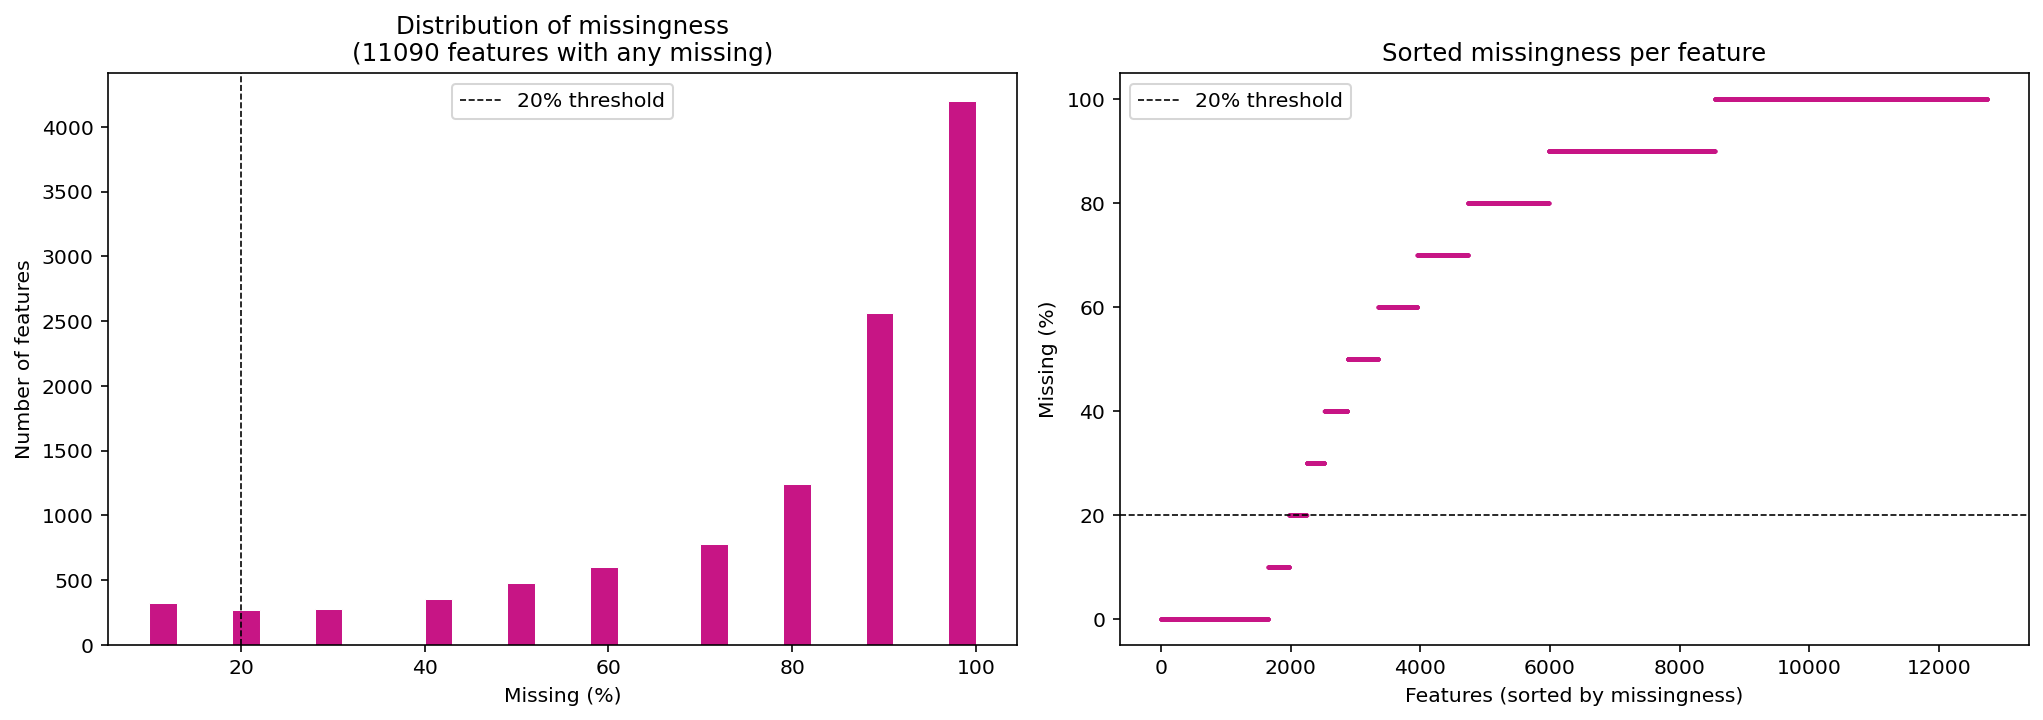

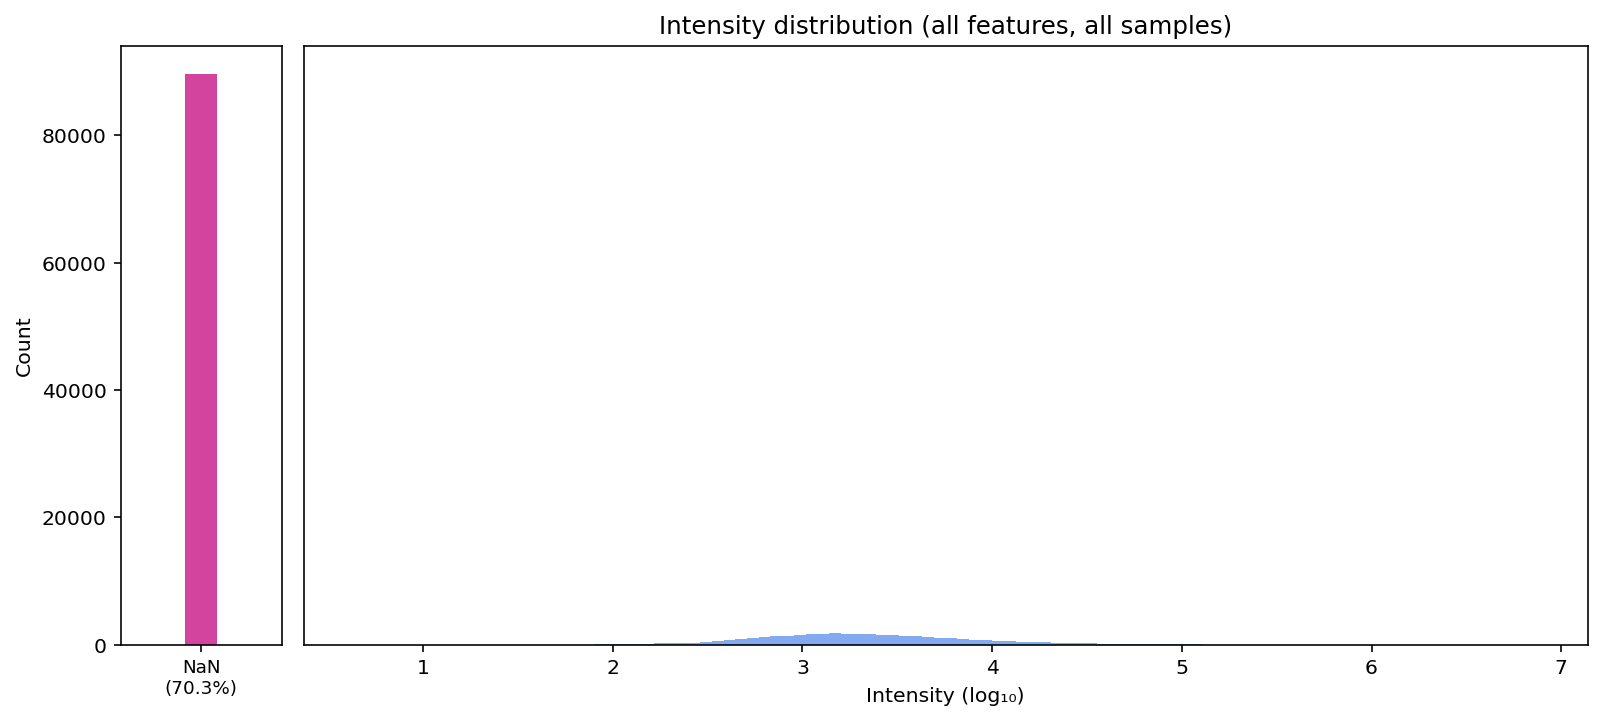

In [63]:
plot_feature_missingness(data)
plot_intensity_distribution(data)

There are a lot of missing values, so it is important that we filter first.

## 80%-rule for filtering

The 80%-rule filters out features with too much missingness from our data. More
specifically, if for a feature, more than 20% of the data is missing across all sample
columns, it will be removed, so features must have at least 80% of data present in order
to be retained.

Although it is called the 80%-rule, other thresholds can be used to make the filtering
more lenient or more stringent.

In acore, this method is implemented in the function filter_by_missingness. Let's first
have a look at our function.

In [64]:
help(fm.filter_by_missingness)

Help on function filter_by_missingness in module acore.filter_metabolomics:

filter_by_missingness(
    data: pd.DataFrame,
    percent: int = 80,
    method: str = 'classic',
    samples: list | None = None,
    groups: dict | str | None = None
)
    Implementation of the 80%-rule.

    If there are more than 20% of values (intensities) missing for one feature,
    this feature will get removed.

    :param data: pandas data frame with samples as rows and features as columns.
    :param percent: percentage chosen for filtering. The default is 80%, meaning that
        at least 80% of the values of every feature need to be present in order for this
        feature to be retained.
    :param method: str that is either "classic" or "modified".
        If "classic", all samples are considered for each feature. Samples are taken from the
        "samples" parameter and should not include controls or QCs.
        If "modified", conditions are separated when calculating the percentage of
   

In [65]:
data_filtered_1 = fm.filter_by_missingness(
    data=data,
    method="classic",
    percent=80,  # 80% present, 20% missing is allowed at most
    samples=samples,
)

In [66]:
print(
    f"Num. of features before filtering: {data.shape[1]}\n"
    f"Num. of features after filtering: {data_filtered_1.shape[1]}"
)
print(f"Difference: {data.shape[1]-data_filtered_1.shape[1]} features removed.")

Num. of features before filtering: 12747
Num. of features after filtering: 2402
Difference: 10345 features removed.


In [67]:
data.isna().sum().sum()
missing_per_feature = data_filtered_1.isna().sum(axis=0)
missing_per_feature
freq_table = missing_per_feature.value_counts().sort_index()

df_freq = freq_table.reset_index()
df_freq.columns = ["n_missing", "n_features"]

df_freq

,n_missing,n_features
0,0,"1,657"
1,1,323
2,2,134
3,3,115
4,4,103
5,5,70


Now we have removed a huge number of features, and we have 2402 features left, which is a number we can trust more to contain real metabolites.

## CV-based filtering
In this method, we are taking into account the quality control (QC) samples.

The CV of the biological samples and the CV of the QC samples are calculated per
feature, and if for a given feature the CV of the QC samples is larger than that of the
biological samples, it is removed. Also, if there are not enough QC samples to calculate
the CV, or the mean is near zero, the features will be removed.

In acore, this method is implemented in the function filter_cv.

In [68]:
data_filtered_2 = fm.filter_cv(data=data_filtered_1, samples=samples, qcs=qcs)

CV is undefined for 232 feature(s) in QC samples (zero or near-zero mean): ['3908070396176125293', '12001520309928230012', '13566686864077761070', '9598231282994165099', '5190461339620710491', '1521011901685717522', '3370841807118222510', '3187723228169285960', '11698558759228342657', '1709980702633306538', '8988152864547520803', '1987162592851467325', '12059740800691591604', '5486845592690556538', '9699743031934743852', '14642679977206888236', '10261123663459887884', '14108071356510229752', '2333067784425102943', '17163020620599571348', '11219733102422973687', '16419740817988778726', '12657019742918966735', '15018155437166252936', '5771350104112103795', '2274114662102459438', '9173518930902254578', '16383773908447362437', '11568971948182079798', '15818317413538340152', '11214649254165383189', '13652556636532165845', '9053770804385176638', '13181890625550436121', '15633721928265036958', '1186308595181602545', '11017994451908153319', '2391855080421519305', '3038027812233963283', '139280

In [69]:
print(
    f"Num. of features before filtering: {data_filtered_1.shape[1]}\n"
    f"Num. of features after filtering: {data_filtered_2.shape[1]}"
)
print(
    f"Difference: {data_filtered_1.shape[1]-data_filtered_2.shape[1]} features removed."
)

Num. of features before filtering: 2402
Num. of features after filtering: 1891
Difference: 511 features removed.


## D-ratio filtering
Finally, we will do dispersion ratio filtering.

This method scores each feature by the ratio of its analytical noise (QC) to its total
variation, meaning the standard deviation across pooled QC injections divided by the
standard deviation across biological samples.

A low D-ratio means biological variation dominates the technical noise, and a high one
means the feature is mostly measurement noise with little biological signal, so features
above a threshold (typically 0.5 or lower) get removed.

Here, we will use the median absolute deviation (MAD, scaled by 1.4826). Because medians
ignore extreme values, this version resists outliers and skew, making it the better
choice for non-Gaussian data like raw untargeted peak areas — whereas the
standard-deviation version is preferable when the data are roughly Gaussian (or have
been log-transformed first).

This method is not implemented in acore yet, so we will define it ourselves.

In [70]:
def filter_dratio(
    data: pd.DataFrame,
    samples: list,
    qcs: list,
    threshold: float = 0.5,
):
    if len(qcs) < 2:
        raise ValueError(
            f"You need more than 1 QC sample to apply this filtering method. Got {len(qcs)}."
        )
    if len(samples) < 2:
        raise ValueError(
            f"You need more than 1 biological sample to apply this filtering method. "
            f"Got {len(samples)}."
        )

    def mad(df):  # median absolute deviation
        # 1.4826 * median(|x - median(x)|), an unbiased SD estimate for Gaussian data.
        med = df.median()
        return 1.4826 * (df - med).abs().median()

    df = data.copy()

    disp_qcs = mad(df.loc[qcs])
    disp_samples = mad(df.loc[samples])
    dratio = disp_qcs / disp_samples

    undefined = dratio.isna() | dratio.isin([np.inf, -np.inf])
    if undefined.any():
        print(
            f"D-ratio is undefined for {undefined.sum()} feature(s) (zero or near-zero biological "
            f"dispersion): {list(df.columns[undefined])}. These features will be dropped.",
        )

    keep = (dratio <= threshold) & ~undefined

    return df.loc[:, keep]

In [71]:
data_filtered_3 = filter_dratio(
    data=data_filtered_2, samples=samples, qcs=qcs, threshold=0.4
)

In [72]:
print(
    f"Num. of features before filtering: {data_filtered_2.shape[1]}\n"
    f"Num. of features after filtering: {data_filtered_3.shape[1]}"
)
print(
    f"Difference: {data_filtered_2.shape[1]-data_filtered_3.shape[1]} features removed."
)

Num. of features before filtering: 1891
Num. of features after filtering: 1286
Difference: 605 features removed.


In [73]:
print(f"Now we have a total of {data_filtered_3.shape[1]} features left.")

Now we have a total of 1286 features left.


In [74]:
data_filtered_3.isna().sum().sum()
missing_per_feature = data_filtered_3.isna().sum(axis=0)
missing_per_feature
freq_table = missing_per_feature.value_counts().sort_index()

df_freq = freq_table.reset_index()
df_freq.columns = ["n_missing", "n_features"]

df_freq

,n_missing,n_features
0,0,998
1,1,199
2,2,71
3,3,18


## Imputation

While we have filtered out a lot of missingness, we still have missing values in our
data. Those are filled in with imputation. Imputation methods for metabolomics are also
implemented in acore. Here we will use the half minimum to impute our values with.

In [75]:
from acore.imputation_analysis import (
    imputation_half_minimum,
    imputation_zeros,
)

But first, let's re-assess how much we need to fill in.

Total count of missing cells: 395
Overall percentage of missingness: 3.07153965785381



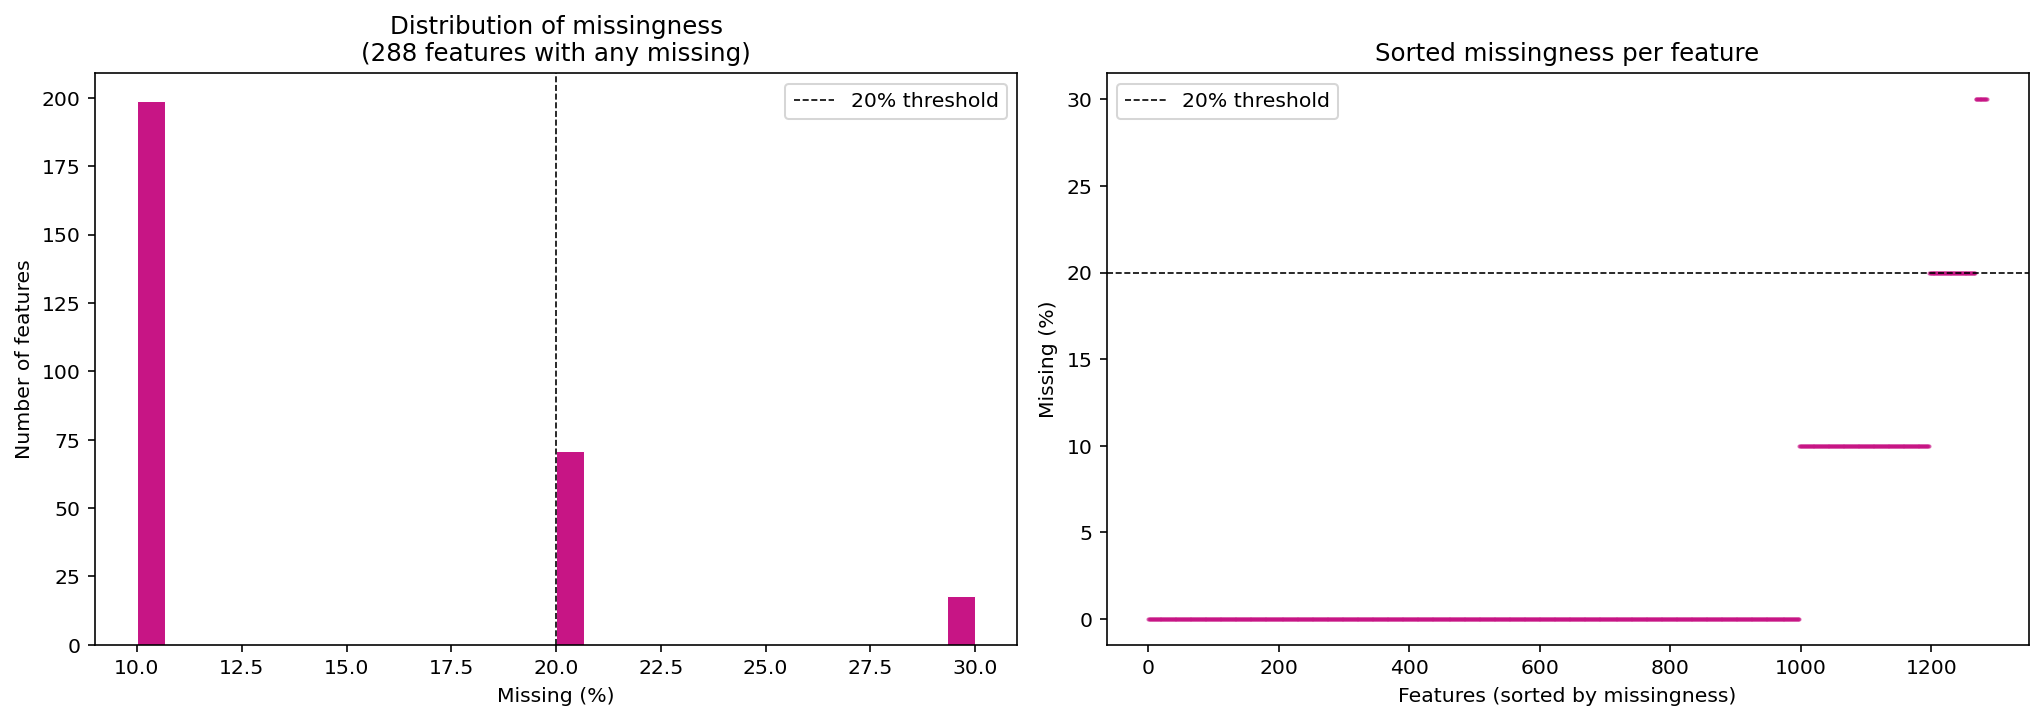

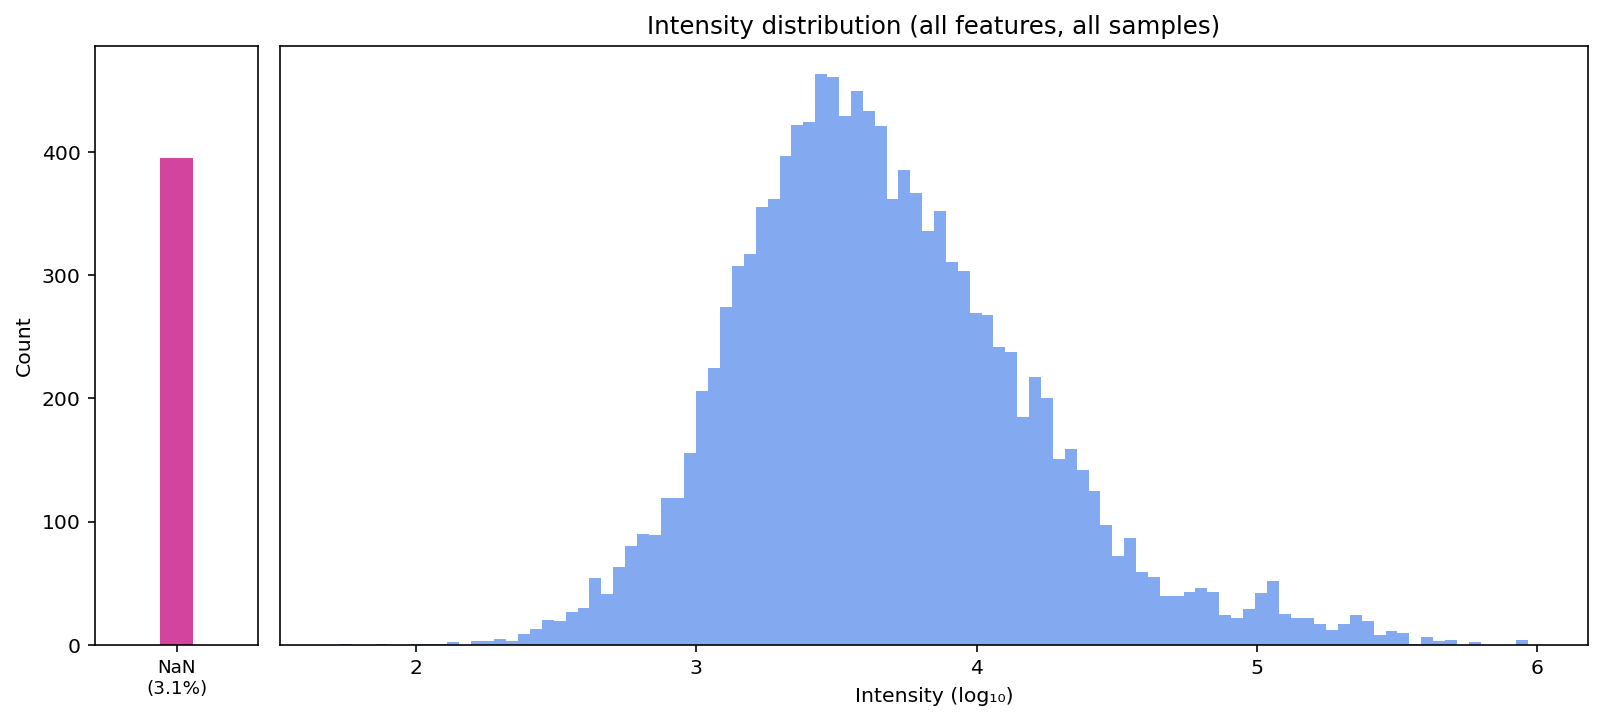

In [76]:
print(f"Total count of missing cells: {data_filtered_3.isnull().sum().sum()}")
print(
    f"Overall percentage of missingness: {data_filtered_3.isnull().mean().mean() * 100}\n"
)

plot_feature_missingness(data_filtered_3)
plot_intensity_distribution(data_filtered_3)

## Impute with half minimum

In this imputation method, we are calculating the minimum of each feature, taking the
half of that and using that value to fill in missing values for that feature. This
method is implemented in the acore function imputation_half_minimum().

Note: Another commonly used method in metabolomics data imputation is imputing with
zeros. This method can also be applied through acore, with the function
imputation_zeros().

In [77]:
data_imputed = imputation_half_minimum(data=data_filtered_3)

In [78]:
data_imputed

id,4843286590468162904,15924628286041590313,471737558304578846,14176084102550772149,10936525985680386434,11798479293910672205,90102547466061970,9365629067704566396,9764079183865417548,6203296351644010412,...,463961811652296826,1368722443019007836,10365896885546056768,16255952552828136880,16827050502602154723,15760718044255921079,11555173356673325579,13770660890084507305,17106765947960431742,11370553721875375420
MS_QC_POOL_1_POS.mzML,225.347,"4,732.835","41,914.310","7,169.480","19,852.830","98,085.810","4,980.488","10,907.860",259.903,"2,196.922",...,"1,845.716","4,215.721","64,971.210",540.031,"1,035.372","4,187.395",525.518,797.108,"2,950.257","7,485.305"
MS_E_POS.mzML,611.827,"3,995.056","44,842.080","10,044.520","26,870.470","66,883.960","6,831.744","12,752.410",907.361,"2,675.932",...,635.731,"1,315.995","44,720.120","1,631.662",117.749,"3,315.487","1,199.529",398.554,"3,110.200","21,912.580"
MS_B_POS.mzML,225.347,"6,214.320","29,318.380","10,667.300","15,866.760","109,487.500","7,178.044","12,104.640","1,040.289","3,898.314",...,"1,271.463","3,717.393","63,329.760","2,269.881",912.179,"5,180.879","1,306.274","99,812.040","6,467.860","21,400.280"
MS_C_POS.mzML,720.442,"4,451.141","48,011.890","18,089.830","23,494.060","17,850.150","12,782.340","14,274.550","1,544.053",583.819,...,"1,440.584","4,788.281","9,046.679",540.031,"1,150.073","1,364.574","2,255.322","65,936.240",763.547,"14,970.610"
MS_A_POS.mzML,701.244,"4,523.311","36,010.990","12,388.890","25,155.210","59,020.210","8,566.932","13,390.520","1,447.252","2,014.040",...,"1,407.186","4,196.551","33,843.600","2,386.909",235.499,"2,729.147","1,617.219","137,745.100","3,648.517","17,832.910"
MS_QC_POOL_4_POS.mzML,538.869,"4,327.155","45,854.070","7,206.025","21,198.210","90,088.900","4,841.615","11,601.080",275.378,"2,119.270",...,"1,837.712","3,912.339","4,523.340","1,346.536","1,042.680","4,128.145",525.518,398.554,"3,105.287","32,428.050"
MS_F_POS.mzML,569.420,"5,416.132","48,687.820","12,321.480","28,426.280","67,483.350","8,580.137","9,595.122",170.597,"1,404.407",...,"1,824.310","4,843.596","37,712.560","1,080.062","1,024.414","3,343.755","1,538.542","74,870.220","1,527.093","15,952.590"
MS_D_POS.mzML,566.403,"4,319.919","36,166.070","14,589.910","24,910.280","84,387.460","10,320.370","13,698.320","1,337.018","2,064.181",...,"2,027.533","2,631.990","4,523.340","1,508.371","1,221.364","4,441.054","1,900.254","103,441.000","2,420.994","21,135.330"
MS_QC_POOL_3_POS.mzML,450.694,"4,781.484","42,201.300","7,445.006","20,012.270","97,400.360","5,164.524","11,943.780",321.012,"2,008.720",...,"1,814.143","4,191.998","65,043.740","1,328.207",117.749,"4,313.705","1,051.037",804.583,"3,109.171","7,485.305"
MS_QC_POOL_2_POS.mzML,451.383,"4,820.588","47,700.360","8,350.301","21,831.970","104,245.800","5,530.938","11,652.400",386.531,"1,720.066",...,"2,036.637","3,909.819","67,764.420","1,109.786",774.700,"4,990.978","1,059.546",398.554,763.547,"32,543.070"


Total count of missing cells: 0
Overall percentage of missingness: 0.0

SUMMARY of imputation changes:
Total values      : 127,470
Missing before    : 89,608  (70.3%)
Missing after     : 0  (0.0%)
Features affected : 11090 / 12747
Samples affected  : 10 / 10


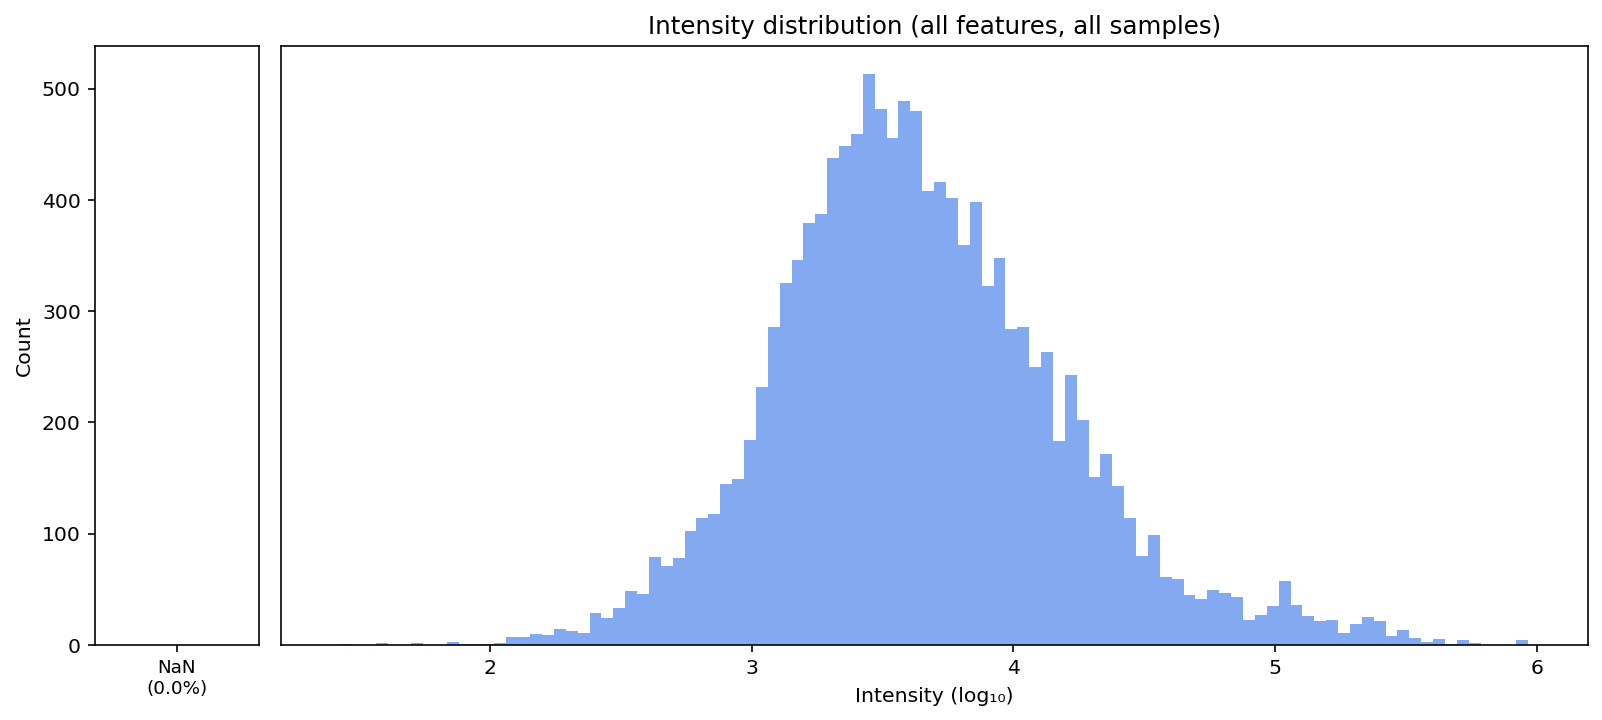

In [79]:
print(f"Total count of missing cells: {data_imputed.isnull().sum().sum()}")
print(
    f"Overall percentage of missingness: {data_imputed.isnull().mean().mean() * 100}\n"
)

print("SUMMARY of imputation changes:")
missingness_summary(data, data_imputed)
plot_intensity_distribution(data_imputed)

Now we have filled in all missing values. We can now plot the data in a PCA plot to see
whether the samples can be separated well with principal components. We can use the
functions we defined earlier at the beginning of the notebook for that.

We can plot the PCA first with all samples and QCs, and then with just the samples, to
see how the groups separate.

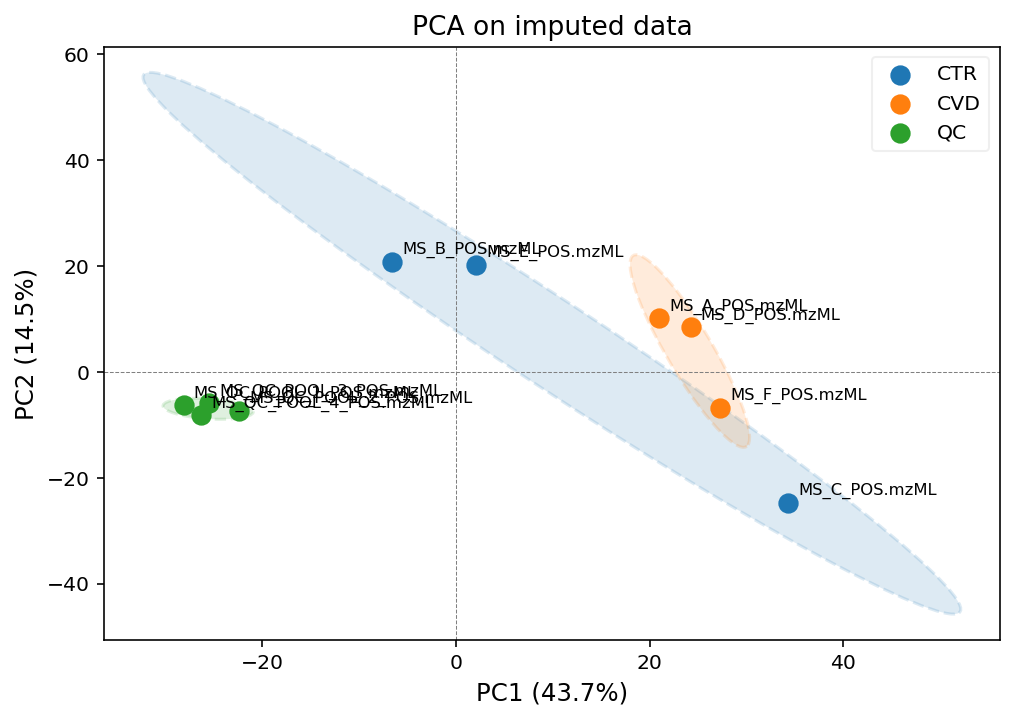

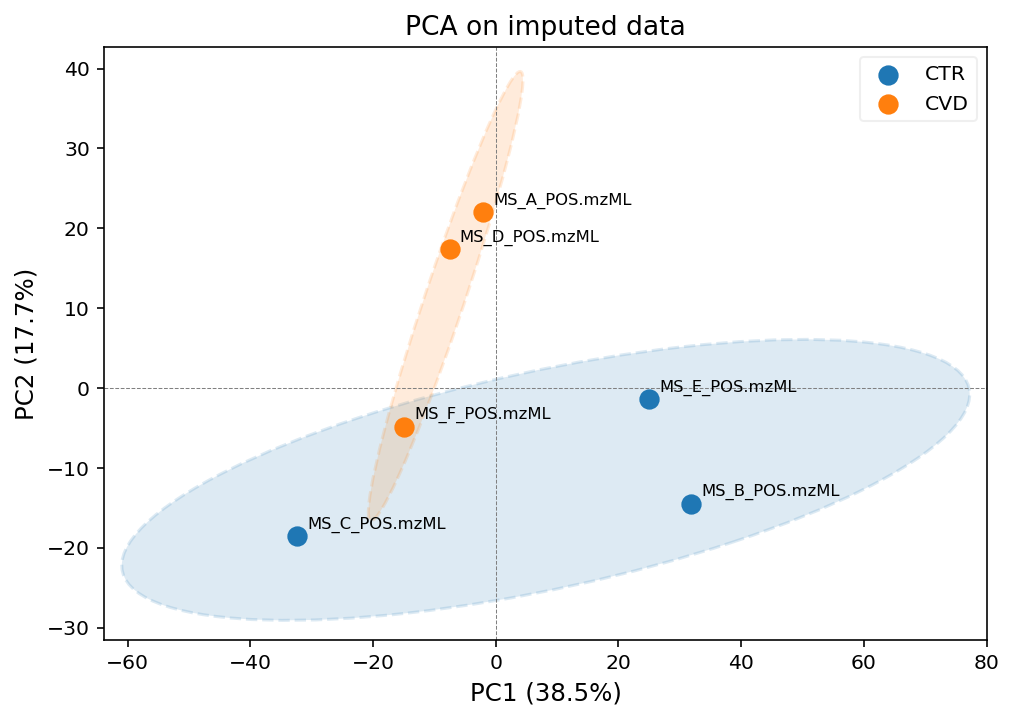

In [80]:
pca_model, scores, var_explained = plot_pca(
    data_imputed, groups_all, label_points=True, title="PCA on imputed data"
)
pca_model, scores, var_explained = plot_pca(
    data_imputed, groups_samples, label_points=True, title="PCA on imputed data"
)

The first plot shows that the QC samples separate quite well from the biological
samples.

The second plot shows that the two groups are also separated quite well, although one of
the control samples, sample C, clusters slightly away from the rest.

## Drift correction

Now that we have a data frame that has been filtered and is fully filled in, we will
look at the within-batch effects. In metabolomics, instrumental drift is common, so the
signal degrades over time.

This is what we have the QC samples for, which is why they are so important to have
included in the study.

We will test two different methods for correcting the instrumental drift in this
notebook, inspect the results, and then choose one to continue with.

In [82]:
from acore import drift_correction as dc

### Loess smoothing drift correction

Pooled QC samples are injected at regular intervals over time throughout the experiment.
The QC intensities for each features should theoretically be consistent in each
measurement. Therefore, any variation in these samples reflect artificial variation, so
instrumental drift, instead of biological variation.

LOESS (LOcally Estimated Scatterplot Smoothing) is a non-parametric regression that fits
a smooth curve through data without assuming a fixed equation. We use it here to fit a
curve over the QC points, and then we rescale the biological sample intensities by the
drift estimate. This will be explained better by the visualisations in the real example
below.

LOESS smoothing based drift correction is implemented in the loess_drift_correction
acore module.

In order to use this method, we need to know the order in which the
samples, including QCs, were run. We have this information in our metadata.

In [83]:
sample_order = pd.read_csv("data/MTBLS8735/metadata.csv").rename(
    columns={"injection_index": "Sample ID", "derived_spectra_data_file": "File Name"}
)
sample_order

,File Name,phenotype,sample_name,age,Sample ID
0,MS_QC_POOL_1_POS.mzML,QC,POOL1,NaN,1
1,MS_A_POS.mzML,CVD,A,53.000,2
2,MS_B_POS.mzML,CTR,B,30.000,3
3,MS_QC_POOL_2_POS.mzML,QC,POOL2,NaN,4
4,MS_C_POS.mzML,CTR,C,66.000,5
5,MS_D_POS.mzML,CVD,D,36.000,6
6,MS_QC_POOL_3_POS.mzML,QC,POOL3,NaN,7
7,MS_E_POS.mzML,CTR,E,66.000,8
8,MS_F_POS.mzML,CVD,F,44.000,9
9,MS_QC_POOL_4_POS.mzML,QC,POOL4,NaN,10


In [84]:
data_corrected_loess, correction_info = dc.run_loess_drift_correction(
    data=data_imputed, qc_rows=qcs, sample_rows=samples, sample_order=sample_order
)
data_corrected_loess

id,4843286590468162904,15924628286041590313,471737558304578846,14176084102550772149,10936525985680386434,11798479293910672205,90102547466061970,9365629067704566396,9764079183865417548,6203296351644010412,...,463961811652296826,1368722443019007836,10365896885546056768,16255952552828136880,16827050502602154723,15760718044255921079,11555173356673325579,13770660890084507305,17106765947960431742,11370553721875375420
MS_QC_POOL_1_POS.mzML,402.532,"4,741.937","42,652.245","7,078.816","20,143.581","96,215.104","4,963.075","11,569.173",273.938,"2,153.886",...,"1,793.597","4,121.022","64,353.344","1,130.877",865.366,"4,077.826",701.532,680.045,"3,710.506","11,075.365"
MS_E_POS.mzML,554.863,"4,144.256","44,044.391","9,802.184","26,526.729","68,591.861","6,808.096","12,597.074",861.656,"2,759.606",...,628.404,"1,327.955","75,802.892","1,504.566",171.522,"3,236.486","1,135.504",432.805,"3,492.199","18,908.597"
MS_B_POS.mzML,292.854,"6,172.450","29,214.489","10,155.370","15,839.884","106,270.627","6,948.579","12,376.569",964.955,"4,077.937",...,"1,221.155","3,676.607","60,566.595","3,125.234","1,076.239","4,854.175","1,233.687","91,873.128","9,373.535","25,341.248"
MS_C_POS.mzML,771.940,"4,447.027","47,332.323","17,074.443","23,258.174","17,467.679","12,310.586","14,260.291","1,371.854",625.683,...,"1,387.153","4,777.291","9,429.085",590.585,"1,757.648","1,271.305","1,893.765","64,620.384","1,093.916","15,389.405"
MS_A_POS.mzML,"1,045.597","4,504.266","36,207.686","11,966.186","25,288.676","57,451.349","8,387.706","13,920.114","1,413.430","2,049.620",...,"1,356.819","4,128.278","32,461.731","3,915.827",234.698,"2,595.316","1,746.101","122,358.600","5,014.937","23,244.525"
MS_QC_POOL_4_POS.mzML,460.127,"4,703.106","45,105.936","7,407.553","20,961.208","97,682.564","5,077.971","11,551.122",300.796,"2,043.426",...,"1,871.731","3,983.650","25,689.953","1,197.681","1,106.009","4,312.067",705.184,480.557,"2,776.189","24,476.983"
MS_F_POS.mzML,499.064,"5,737.462","47,850.097","12,303.796","28,080.559","70,976.986","8,745.932","9,501.134",171.831,"1,405.344",...,"1,828.428","4,908.231","94,236.286",971.565,"1,296.743","3,363.679","1,667.012","85,171.863","1,533.501","12,916.825"
MS_D_POS.mzML,566.760,"4,352.933","35,564.944","13,841.967","24,611.644","83,489.056","9,997.823","13,591.320","1,193.812","2,204.857",...,"1,964.038","2,635.932","5,205.556","1,529.888","1,968.709","4,172.279","1,596.310","104,550.726","3,272.025","20,485.790"
MS_QC_POOL_3_POS.mzML,426.937,"4,878.454","41,453.830","7,142.495","19,755.725","97,877.165","5,060.302","11,806.192",292.999,"2,117.756",...,"1,772.867","4,213.868","87,190.907","1,273.945",186.745,"4,116.213",917.495,840.796,"3,863.711","6,852.070"
MS_QC_POOL_2_POS.mzML,526.797,"4,793.274","47,226.643","7,889.858","21,685.596","101,363.731","5,325.251","11,757.656",347.679,"1,830.721",...,"1,955.355","3,884.870","66,558.055","1,340.499","1,060.326","4,645.157",923.695,378.856,"1,121.601","35,695.004"


Our dataframe has the same structure as before.

We can also look at the object correction_info, if we want to trace the exact correction
that was applied to every feature.

In [85]:
correction_info[data_corrected_loess.columns[0]]

{'alpha': np.float64(0.9999999999999999),
 'drift_curve': [514.6233220110844,
  497.3432851829259,
  420.94867391258504,
  302.4950117649153,
  347.0676587448362,
  450.7548801669397,
  252.50237980994558,
  386.46923978297167,
  476.13677757929884,
  528.2258070970373],
 'y_qc': [225.3471, 451.38278, 450.6942, 538.8692],
 'x_qc': [1, 4, 7, 10],
 'rsd_qc': np.float64(27.86580900151947),
 'median': np.float64(451.03849),
 'y_all': [569.4197,
  611.8272,
  720.4418,
  701.24396,
  225.3471,
  566.40344,
  225.3471,
  451.38278,
  450.6942,
  538.8692],
 'new_values': [499.0644432137127,
  554.8634608134482,
  771.9396727981167,
  1045.5974628957663,
  292.8541831798992,
  566.759814588787,
  402.5317139045657,
  526.7974434848481,
  426.9370504274949,
  460.1266106463794],
 'status': 'corrected'}

To understand better what is happening, we can plot a single feature with
all its measurements over time, and the loess curve that is calculated over it. We can
try out a few different features to see what would happen, and also try different
smoothing parameters to see how the curve changes.

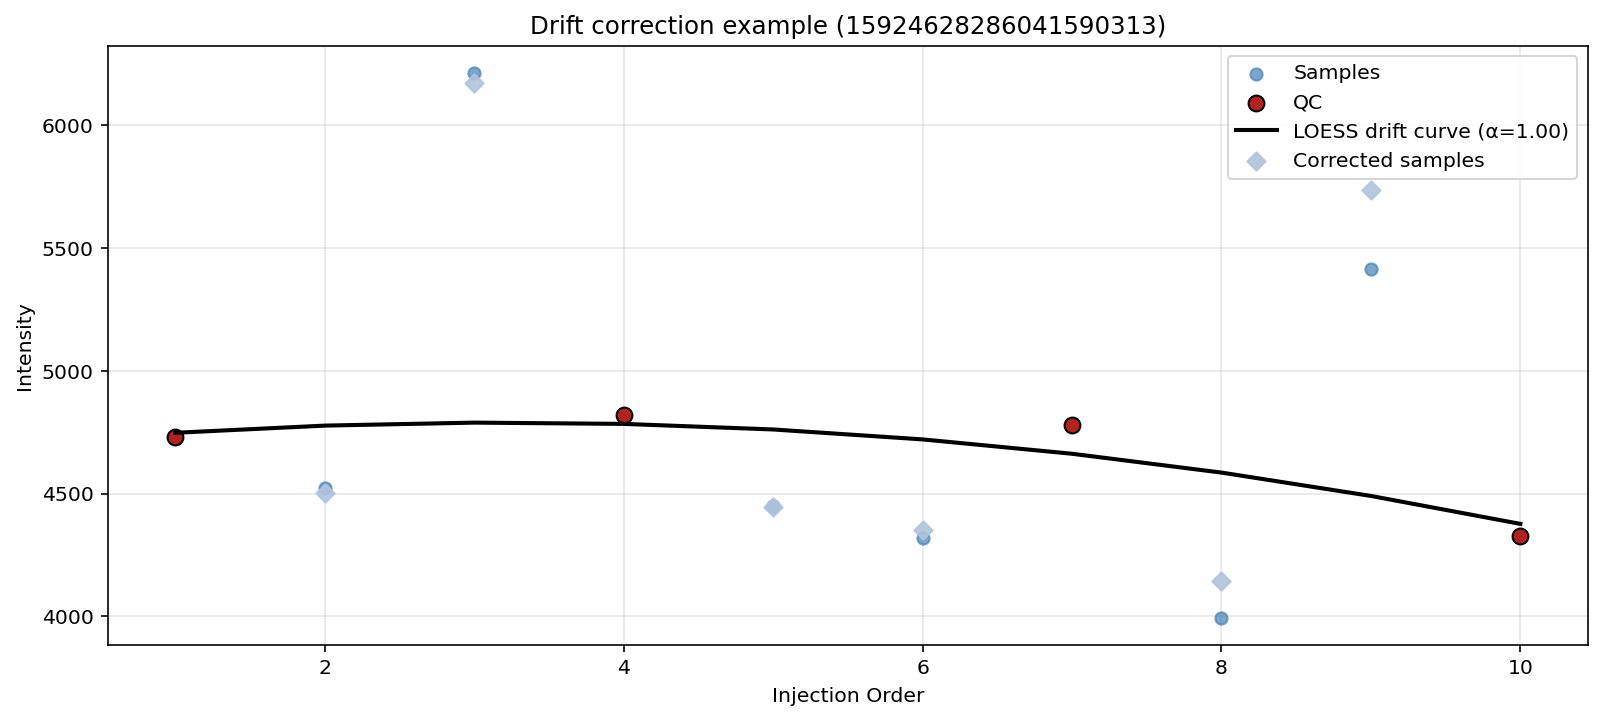

In [90]:
plot_loess_example_curve(
    df=data_imputed,
    feature_idx=1,
    samples=samples,
    qcs=qcs,
    sample_order=sample_order,
)

### CPCA

Standard PCA finds orthogonal directions (principal components) that capture maximum
variance in a single dataset. Common PCA extends this to multiple groups: instead of
computing separate components per batch, it tries to find a set of components that are
common across groups.

In this case, it finds the principal components that are common across all samples,
because the assumption is that those are the ones that are due to artificial variation,
whereas the variance in biological samples will not be shared across all.

First, we can plot a PCA for this purpose.

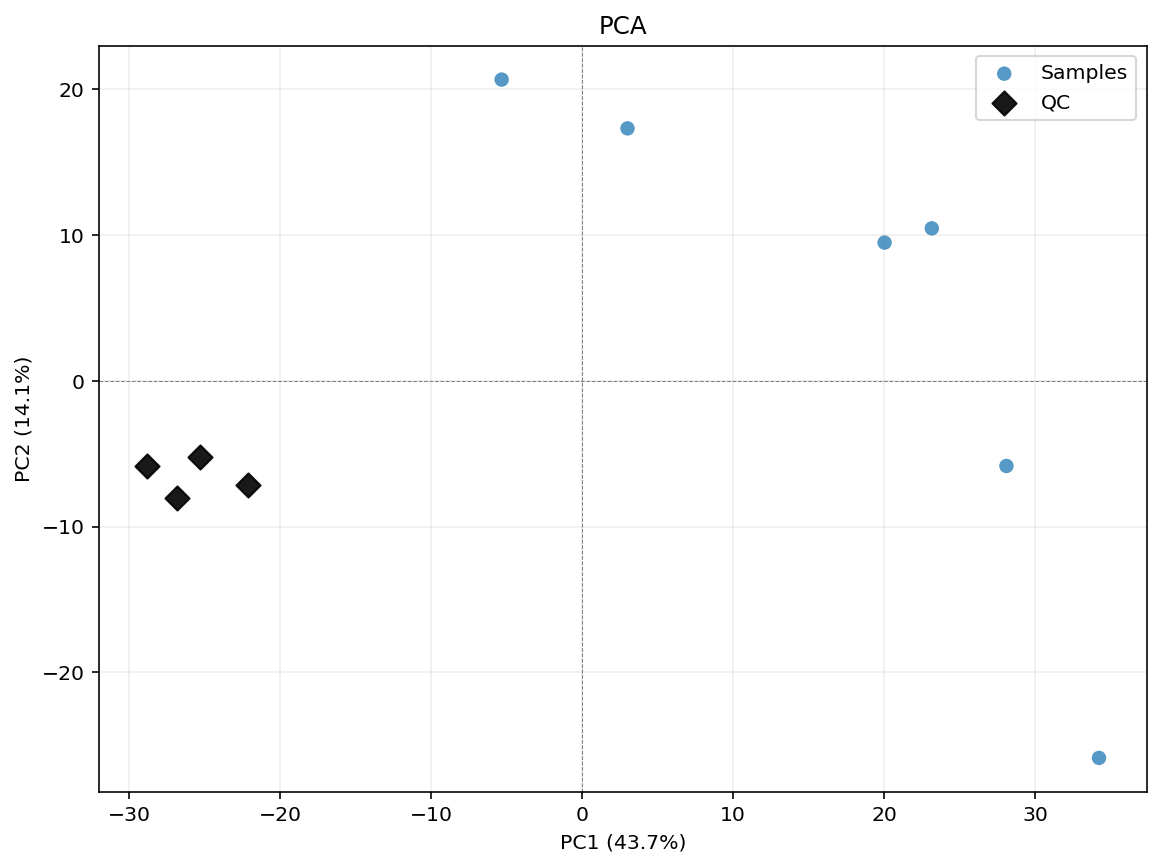

In [91]:
pca_for_cpca_drift(
    data_imputed,
    samples=samples,  # list of col names, OR dict {group_name: [col names]}
    qcs=qcs,
    log_transform=True,
    title="PCA",
)

The QC samples are already quite close together, but there is some variation.

We can use the acore function cpca_drift_correction for this.


In [92]:
data_corrected_cpca = dc.run_cpca_drift_correction(
    data_imputed, sample_rows=samples, qc_rows=qcs, n_comps=1
)

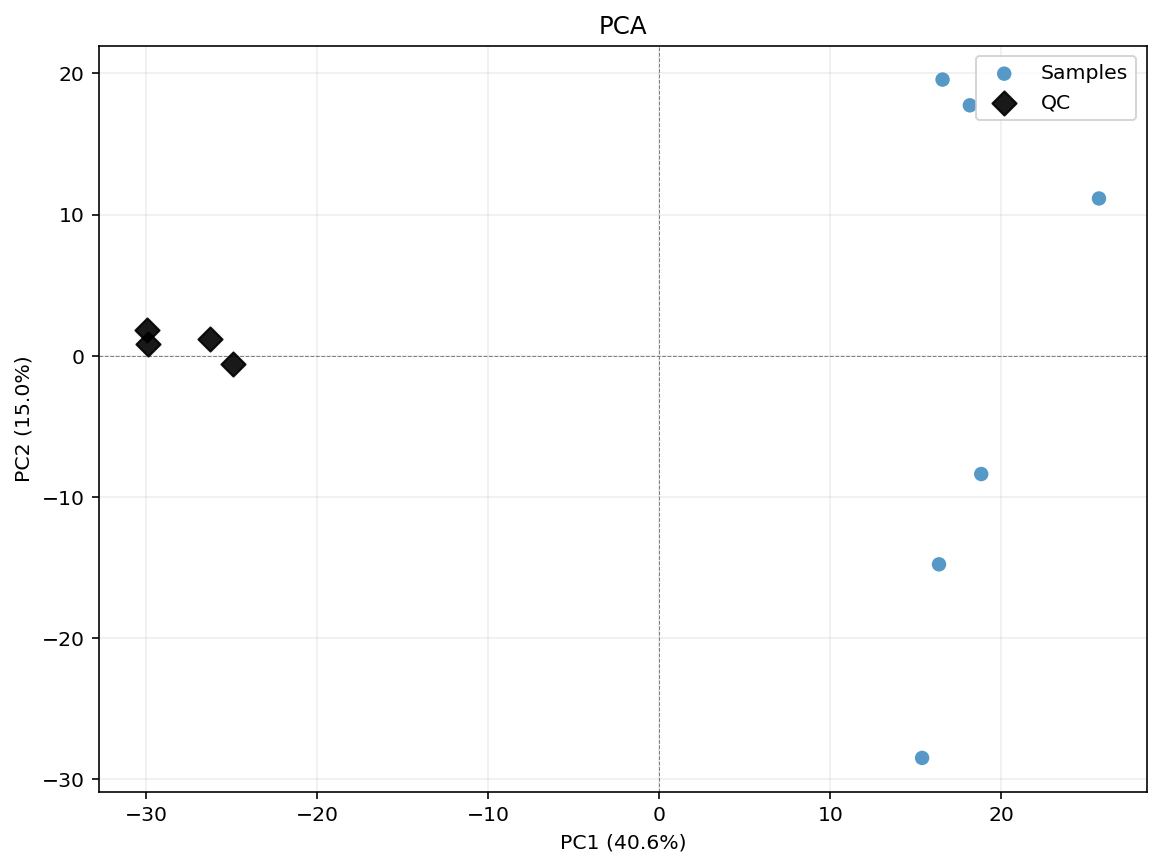

In [93]:
pca_for_cpca_drift(
    data_corrected_cpca,
    samples=samples,  # list of col names, OR dict {group_name: [col names]}
    qcs=qcs,
    log_transform=True,
    title="PCA",
)

In [94]:
df_corrected_2comps = dc.run_cpca_drift_correction(
    data_imputed, samples, qcs, n_comps=2
)
df_corrected_3comps = dc.run_cpca_drift_correction(
    data_imputed, samples, qcs, n_comps=3
)
df_corrected_4comps = dc.run_cpca_drift_correction(
    data_imputed, samples, qcs, n_comps=4
)

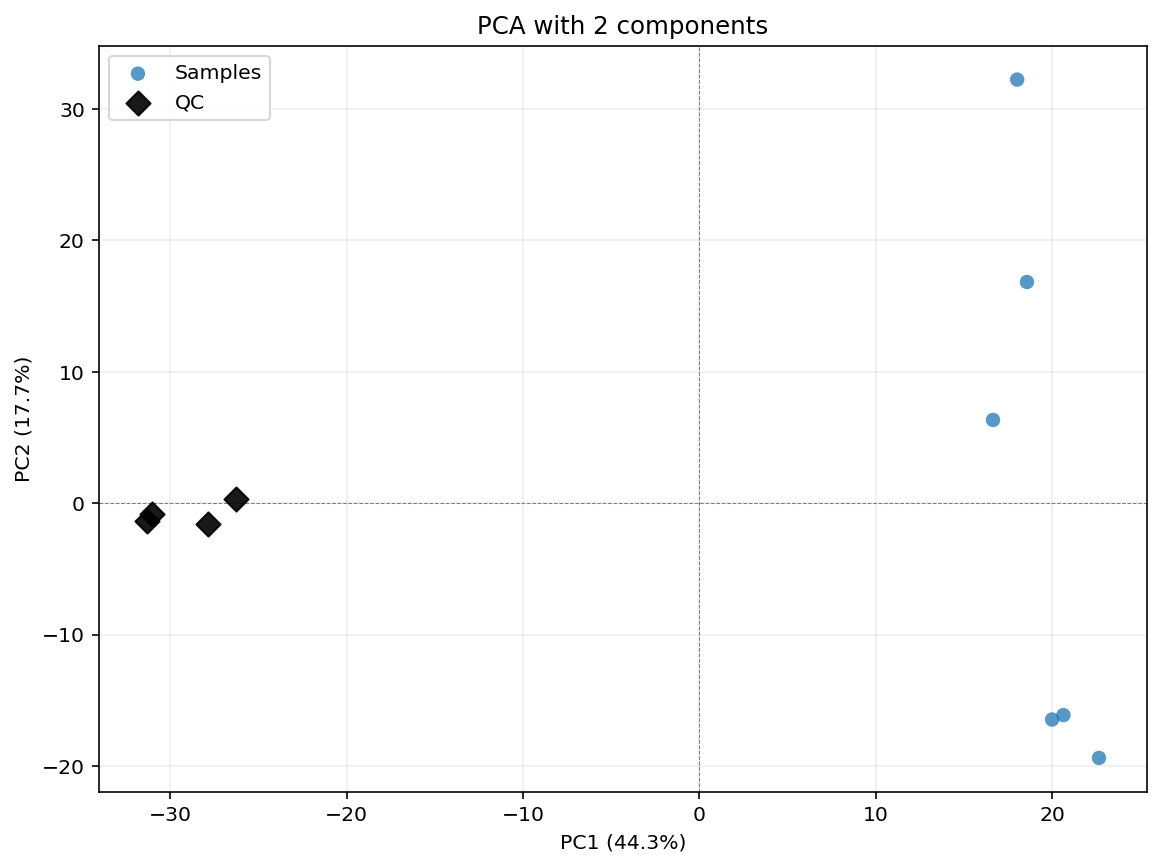

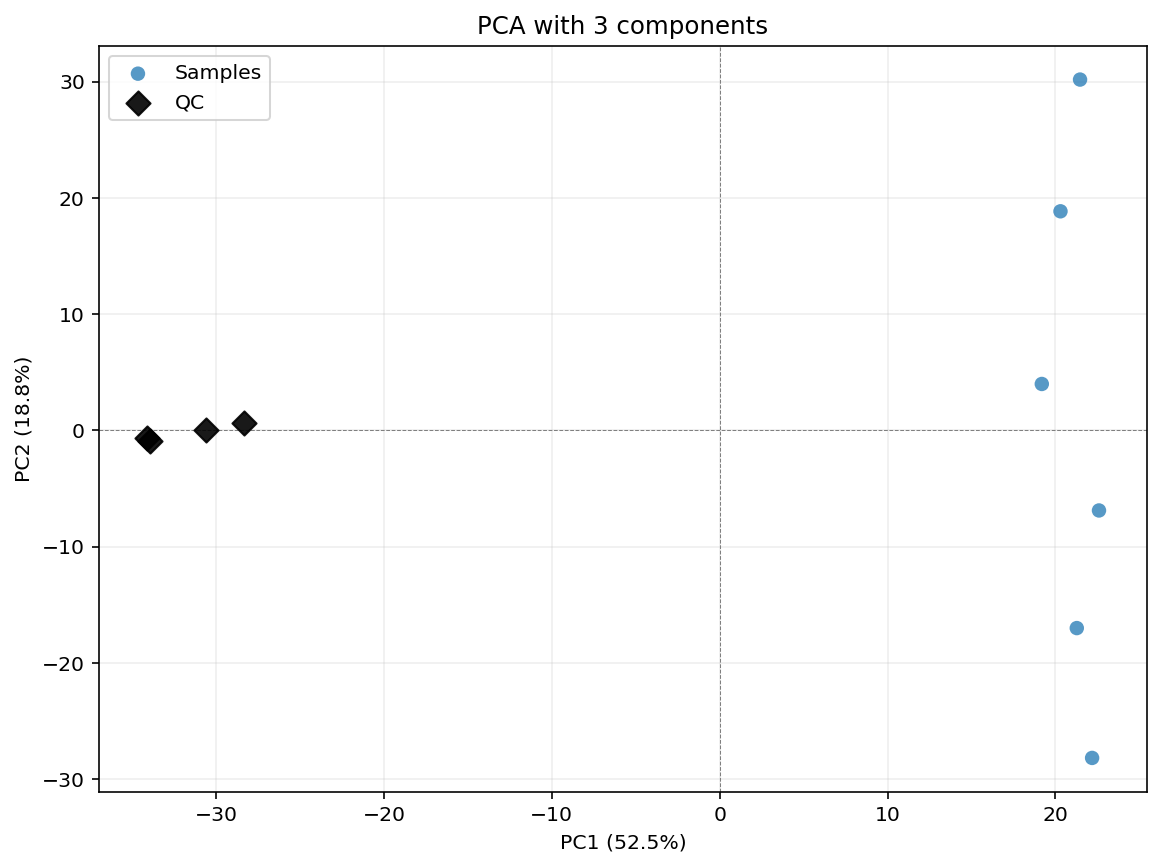

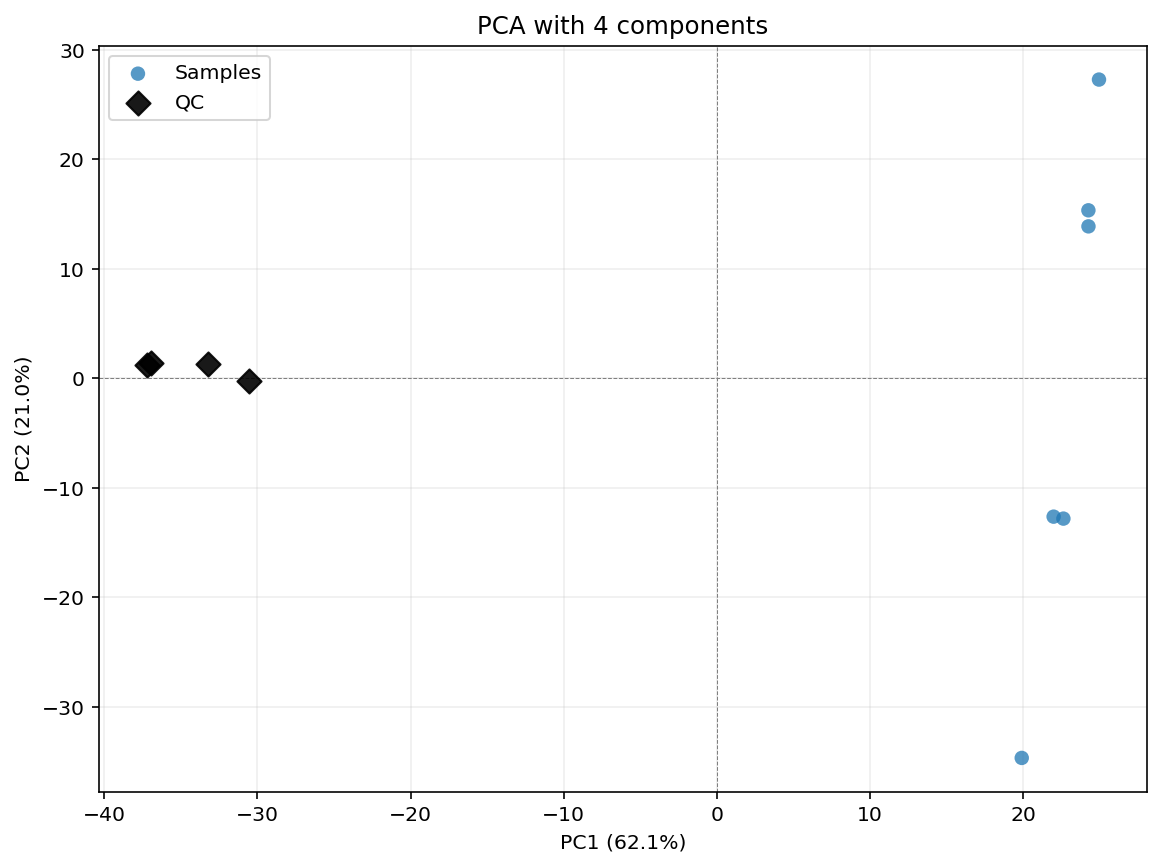

In [95]:
pca_for_cpca_drift(
    df_corrected_2comps,
    samples,
    qcs,
    log_transform=True,
    title="PCA with 2 components",
)

pca_for_cpca_drift(
    df_corrected_3comps,
    samples,
    qcs,
    log_transform=True,
    title="PCA with 3 components",
)

pca_for_cpca_drift(
    df_corrected_4comps,
    samples,
    qcs,
    log_transform=True,
    title="PCA with 4 components",
)

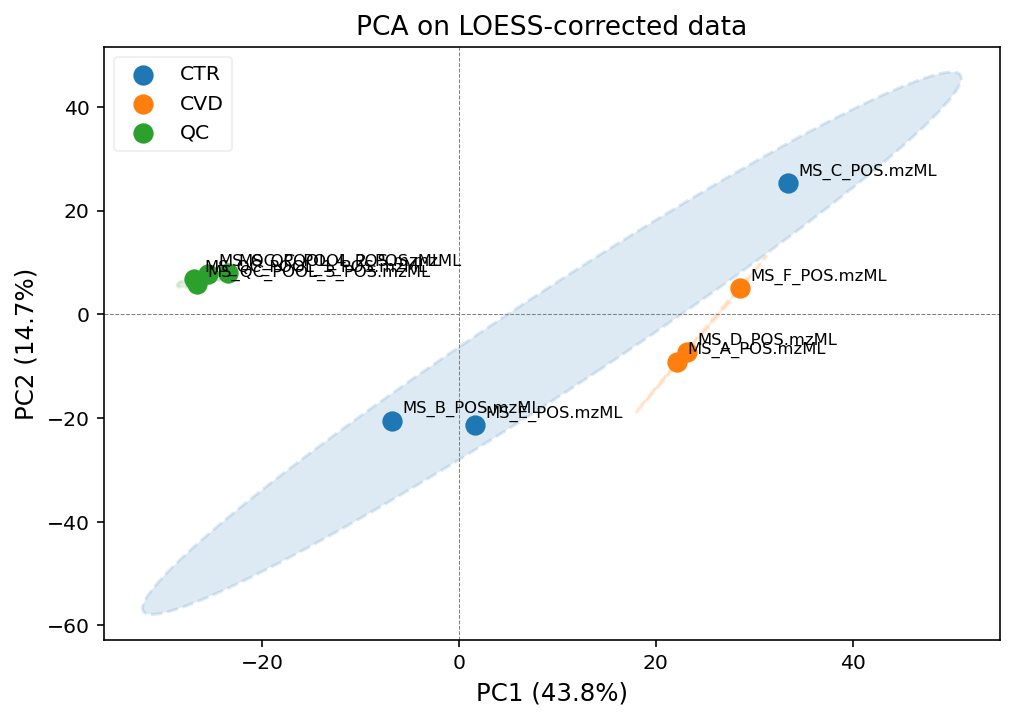

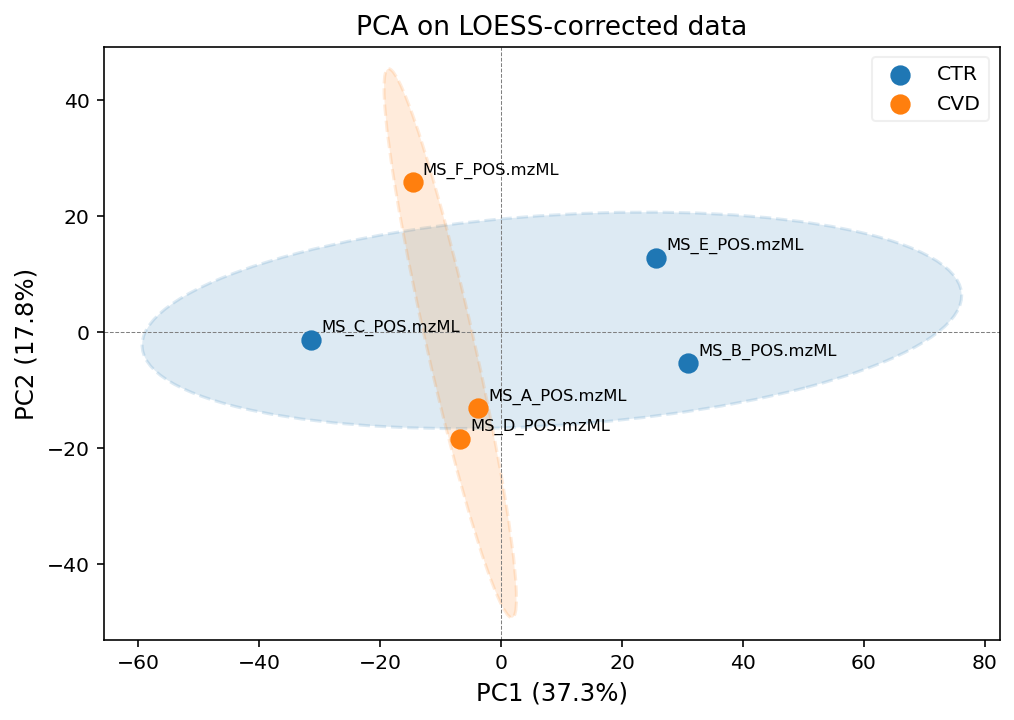

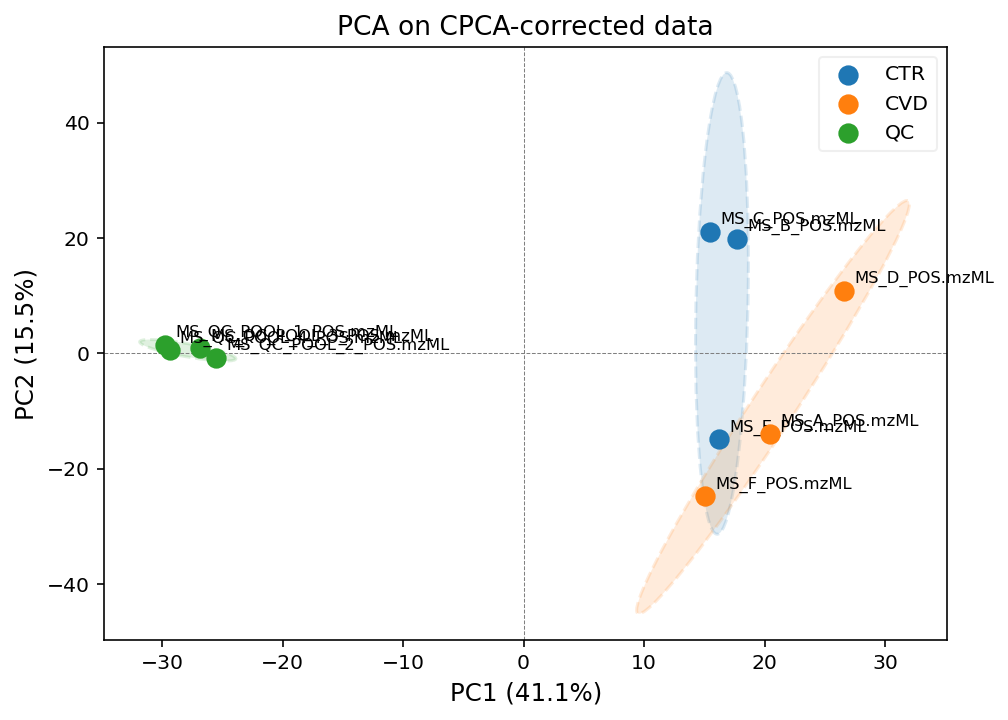

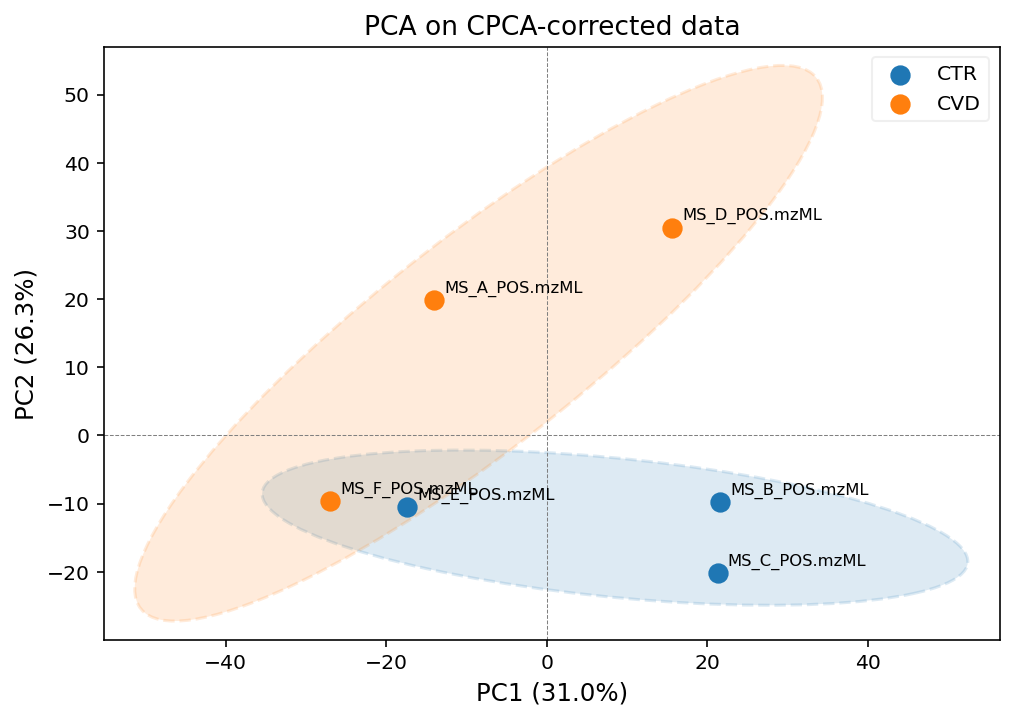

In [96]:
pca_model, scores, var_explained = plot_pca(
    data_corrected_loess,
    groups_all,
    label_points=True,
    title="PCA on LOESS-corrected data",
)
pca_model, scores, var_explained = plot_pca(
    data_corrected_loess,
    groups_samples,
    label_points=True,
    title="PCA on LOESS-corrected data",
)
pca_model, scores, var_explained = plot_pca(
    data_corrected_cpca,
    groups_all,
    label_points=True,
    title="PCA on CPCA-corrected data",
)
pca_model, scores, var_explained = plot_pca(
    data_corrected_cpca,
    groups_samples,
    label_points=True,
    title="PCA on CPCA-corrected data",
)

We will continue with the LOESS corrected data. 

## Normalization

We will also normalise the data with Z-score normalisation. In this case, this will be
mainly for visualisation purposes, again to see whether the data is separating well.

We will use an acore function for this again.

In [97]:
from acore import normalization

In [98]:
data_normalized = normalization.normalize_data(data_corrected_loess, "zscore")
data_normalized

id,4843286590468162904,15924628286041590313,471737558304578846,14176084102550772149,10936525985680386434,11798479293910672205,90102547466061970,9365629067704566396,9764079183865417548,6203296351644010412,...,463961811652296826,1368722443019007836,10365896885546056768,16255952552828136880,16827050502602154723,15760718044255921079,11555173356673325579,13770660890084507305,17106765947960431742,11370553721875375420
MS_QC_POOL_1_POS.mzML,-0.286,-0.175,0.801,-0.114,0.222,2.180,-0.169,0.001,-0.290,-0.241,...,-0.250,-0.191,1.360,-0.267,-0.274,-0.192,-0.279,-0.279,-0.201,-0.012
MS_E_POS.mzML,-0.355,-0.254,0.877,-0.093,0.381,1.573,-0.178,-0.014,-0.347,-0.293,...,-0.353,-0.334,1.777,-0.329,-0.366,-0.279,-0.339,-0.359,-0.272,0.165
MS_B_POS.mzML,-0.354,-0.180,0.504,-0.062,0.107,2.789,-0.157,0.004,-0.334,-0.242,...,-0.327,-0.254,1.433,-0.270,-0.331,-0.219,-0.326,2.362,-0.085,0.389
MS_C_POS.mzML,-0.334,-0.232,0.967,0.121,0.294,0.132,-0.012,0.043,-0.317,-0.338,...,-0.317,-0.222,-0.092,-0.339,-0.307,-0.320,-0.303,1.450,-0.325,0.074
MS_A_POS.mzML,-0.322,-0.235,0.567,-0.046,0.291,1.104,-0.137,0.003,-0.313,-0.297,...,-0.315,-0.245,0.472,-0.250,-0.343,-0.283,-0.305,2.745,-0.222,0.239
MS_QC_POOL_4_POS.mzML,-0.278,-0.171,0.848,-0.103,0.239,2.175,-0.162,0.002,-0.282,-0.238,...,-0.243,-0.189,0.358,-0.260,-0.262,-0.181,-0.272,-0.278,-0.220,0.328
MS_F_POS.mzML,-0.370,-0.214,1.043,-0.018,0.453,1.733,-0.124,-0.101,-0.380,-0.343,...,-0.330,-0.238,2.427,-0.356,-0.346,-0.285,-0.335,2.156,-0.339,0.001
MS_D_POS.mzML,-0.405,-0.278,0.767,0.040,0.400,2.372,-0.089,0.031,-0.384,-0.350,...,-0.358,-0.336,-0.250,-0.373,-0.358,-0.284,-0.370,3.077,-0.314,0.262
MS_QC_POOL_3_POS.mzML,-0.286,-0.174,0.748,-0.116,0.201,2.171,-0.169,0.001,-0.289,-0.243,...,-0.252,-0.190,1.901,-0.264,-0.292,-0.193,-0.273,-0.275,-0.199,-0.124
MS_QC_POOL_2_POS.mzML,-0.275,-0.171,0.859,-0.096,0.239,2.173,-0.158,-0.002,-0.279,-0.243,...,-0.240,-0.193,1.328,-0.255,-0.262,-0.175,-0.265,-0.278,-0.260,0.579


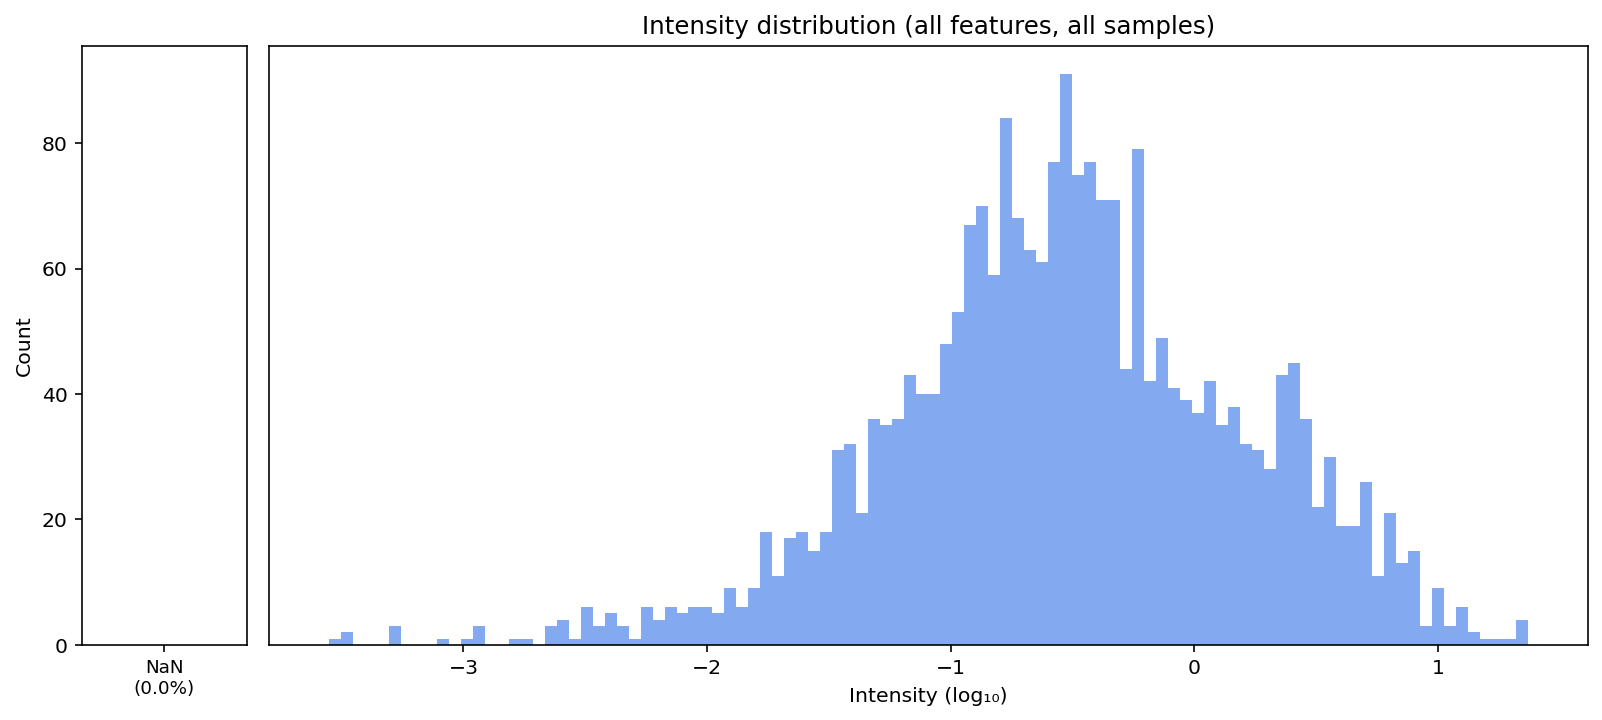

In [99]:
plot_intensity_distribution(data_normalized)

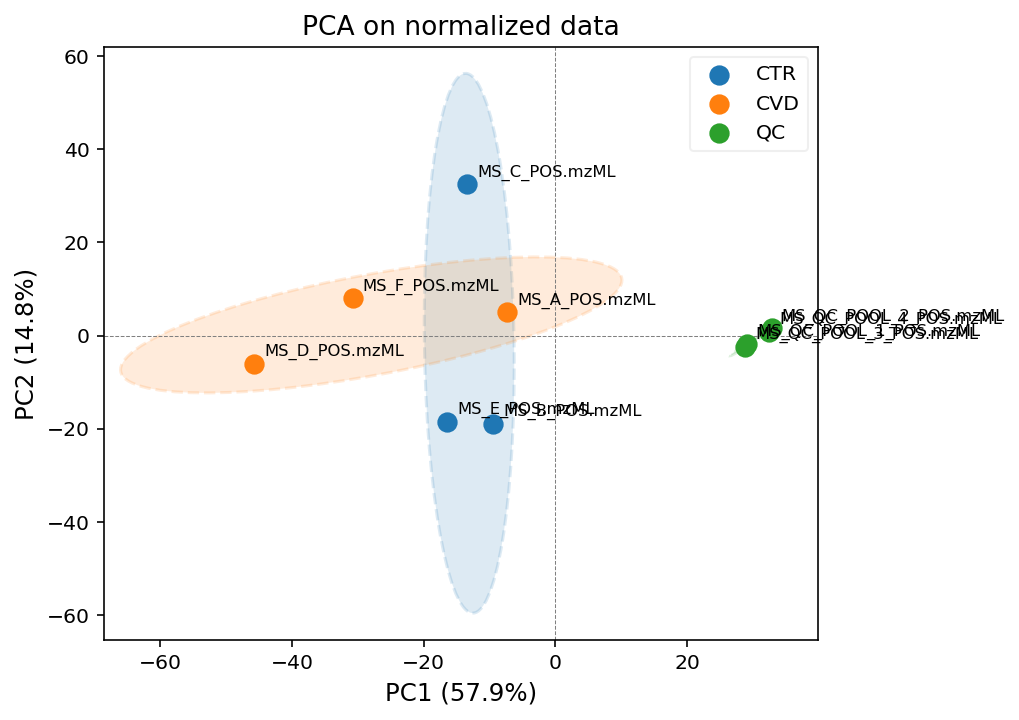

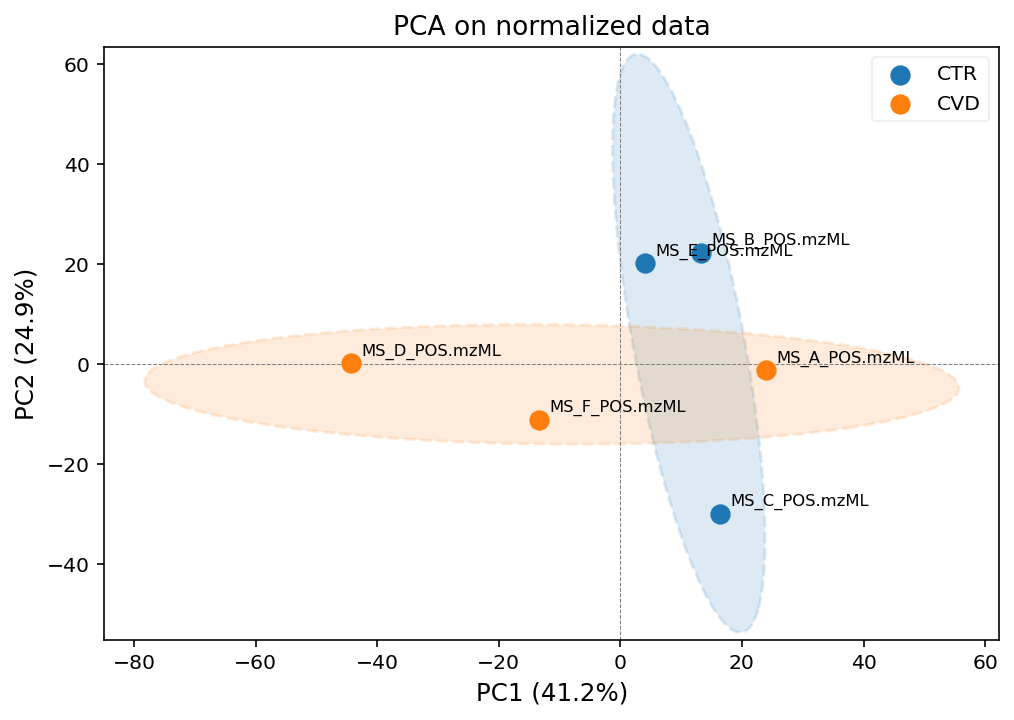

In [100]:
pca_model, scores, var_explained = plot_pca(
    data_normalized, groups_all, label_points=True, title="PCA on normalized data"
)
pca_model, scores, var_explained = plot_pca(
    data_normalized, groups_samples, label_points=True, title="PCA on normalized data"
)

We can see that sample C is still distorting the separation. To know what went wrong with this control, we would need to know more about the sample preparation and background about the patients.

## Statistical analysis

### ANCOVA

We will now do a statistical analysis. We want to find out which ones of our metabolites
are significantly more abundant in the cardiovascular disease group vs the control, or
the other way around.

For this, we will do an ANCOVA (analysis of covariance), which compares group means on
an outcome while statistically controlling for one or more continuous variables
(covariates) that also influence the outcome. In this case, the covariate is age,
because we have this in our metadata and know that it could potentially affect the
sample outcomes.

We are using another acore function for this.

Because the groups did not separate any better after drift correction, we will actually use the imputed dataframe for this. Remember to log transform your data before running an ANCOVA.

In [101]:
import acore.differential_regulation as ad

We need to do some preparation before we can run the function.

In [ ]:
# Create the variable with the data
data_ancova = np.log2(data_imputed)

# Prepare the data to fit the function input
subject_col = data_ancova.index.name or "index"
data_ancova.rename_axis(subject_col, axis=0, inplace=True)

# Add group information to the data frame as a column
group_map = {
    sample: label for label, samples in groups_all.items() for sample in samples
}
data_ancova.insert(0, "group", data_ancova.index.map(group_map))

# Remove the QC samples
data_ancova = data_ancova[data_ancova["group"] != "QC"]

# Add the column of age information
metadata = sample_order.copy().set_index("File Name")
data_ancova.insert(1, "age", metadata.loc[data_ancova.index, "age"])

In [102]:
data_ancova

id,group,age,4843286590468162904,15924628286041590313,471737558304578846,14176084102550772149,10936525985680386434,11798479293910672205,90102547466061970,9365629067704566396,...,463961811652296826,1368722443019007836,10365896885546056768,16255952552828136880,16827050502602154723,15760718044255921079,11555173356673325579,13770660890084507305,17106765947960431742,11370553721875375420
index,,,,,,,,,,,,,,,,,,,,,
MS_E_POS.mzML,CTR,66.000,9.257,11.964,15.453,13.294,14.714,16.029,12.738,13.638,...,9.312,10.362,15.449,10.672,6.880,11.695,10.228,8.639,11.603,14.419
MS_B_POS.mzML,CTR,30.000,7.816,12.601,14.840,13.381,13.954,16.740,12.809,13.563,...,10.312,11.860,15.951,11.148,9.833,12.339,10.351,16.607,12.659,14.385
MS_C_POS.mzML,CTR,66.000,9.493,12.120,15.551,14.143,14.520,14.124,13.642,13.801,...,10.492,12.225,13.143,9.077,10.168,10.414,11.139,16.009,9.577,13.870
MS_A_POS.mzML,CVD,53.000,9.454,12.143,15.136,13.597,14.619,15.849,13.065,13.709,...,10.459,12.035,15.047,11.221,7.880,11.414,10.659,17.072,11.833,14.122
MS_F_POS.mzML,CVD,44.000,9.153,12.403,15.571,13.589,14.795,16.042,13.067,13.228,...,10.833,12.242,15.203,10.077,10.001,11.707,10.587,16.192,10.577,13.962
MS_D_POS.mzML,CVD,36.000,9.146,12.077,15.142,13.833,14.604,16.365,13.333,13.742,...,10.986,11.362,12.143,10.559,10.254,12.117,10.892,16.658,11.241,14.367


Now we can run ANCOVA.

In [103]:
ancova = (
    ad.run_ancova(
        data_ancova.astype({"group": str}),  # ! target needs to be of type str
        # subject=subject_col, # not used
        drop_cols=[],
        group="group",  # needs to be a string
        covariates=["age"],
    )
    .set_index("identifier")
    .sort_values(by="padj")
)  # need to be floats?
ancova

,group1,group2,mean(group1),std(group1),mean(group2),std(group2),posthoc T-Statistics,posthoc pvalue,coef,std err,...,log2FC,FC,F-statistics,pvalue,padj,correction,rejected,-log10 pvalue,Method,posthoc padj
identifier,,,,,,,,,,,,,,,,,,,,,
4252339034979551700,CTR,CVD,12.345,0.644,13.034,0.295,16.322,0.001,0.875,0.054,...,-0.689,0.620,266.411,0.001,0.321,FDR correction BH,False,3.301,One-way ancova,0.321
10071800264895666972,CTR,CVD,13.361,0.817,14.093,0.308,14.248,0.001,0.962,0.067,...,-0.732,0.602,203.015,0.001,0.321,FDR correction BH,False,3.125,One-way ancova,0.321
13355670607852216099,CTR,CVD,12.403,0.040,12.623,0.017,14.357,0.001,0.230,0.016,...,-0.220,0.858,206.112,0.001,0.321,FDR correction BH,False,3.135,One-way ancova,0.321
12876383393801034065,CTR,CVD,16.808,0.543,10.533,0.534,-12.556,0.001,-6.213,0.495,...,6.276,77.478,157.649,0.001,0.350,FDR correction BH,False,2.963,One-way ancova,0.350
3746828480965334286,CTR,CVD,14.185,0.471,14.402,0.162,7.964,0.004,0.348,0.044,...,-0.218,0.860,63.424,0.004,0.387,FDR correction BH,False,2.384,One-way ancova,0.387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3152299178932328488,CTR,CVD,12.211,0.265,12.188,0.517,-0.001,1.000,-0.000,0.393,...,0.023,1.016,0.000,1.000,1.000,FDR correction BH,False,0.000,One-way ancova,1.000
6161725100956116907,CTR,CVD,10.683,0.415,10.720,0.263,-0.001,1.000,-0.000,0.322,...,-0.037,0.975,0.000,1.000,1.000,FDR correction BH,False,0.000,One-way ancova,1.000
6445188435219698607,CTR,CVD,11.580,0.037,11.575,0.202,0.001,1.000,0.000,0.140,...,0.005,1.004,0.000,1.000,1.000,FDR correction BH,False,0.000,One-way ancova,1.000


We are sorting the data by the adjusted pvalue to see what our best hits are, and how good they actually are.
In this case, our best hits have adjusted pvalues of 0.321 and higher, which is quite high, and not significant.

We can inspect the results in a few different ways. First of all, we
can look at the group averages, which are shown in the first six columns.

In [47]:
ancova.iloc[:, :6]

,group1,group2,mean(group1),std(group1),mean(group2),std(group2)
identifier,,,,,,
4252339034979551700,CTR,CVD,12.345,0.644,13.034,0.295
10071800264895666972,CTR,CVD,13.361,0.817,14.093,0.308
13355670607852216099,CTR,CVD,12.403,0.040,12.623,0.017
12876383393801034065,CTR,CVD,16.808,0.543,10.533,0.534
3746828480965334286,CTR,CVD,14.185,0.471,14.402,0.162
...,...,...,...,...,...,...
3152299178932328488,CTR,CVD,12.211,0.265,12.188,0.517
6161725100956116907,CTR,CVD,10.683,0.415,10.720,0.263
6445188435219698607,CTR,CVD,11.580,0.037,11.575,0.202


If we filter to the words below, we can inspect the test results (based on
a linear model) for each feature (on each row). The posthoc values are not interesting
in this case as we are only comparing between two groups (ctr and cvd). We are mainly
interested in the adjusted pvalue (pajd), and in whether the null hypothesis was
rejected or not. If rejected=True, it means our feature was significant according to the
thresholds we have set.

In [48]:
regex_filter = "pval|padj|reject|post"
ancova.filter(regex=regex_filter)

,posthoc T-Statistics,posthoc pvalue,pvalue,padj,rejected,-log10 pvalue,posthoc padj
identifier,,,,,,,
4252339034979551700,16.322,0.001,0.001,0.321,False,3.301,0.321
10071800264895666972,14.248,0.001,0.001,0.321,False,3.125,0.321
13355670607852216099,14.357,0.001,0.001,0.321,False,3.135,0.321
12876383393801034065,-12.556,0.001,0.001,0.350,False,2.963,0.350
3746828480965334286,7.964,0.004,0.004,0.387,False,2.384,0.387
...,...,...,...,...,...,...,...
3152299178932328488,-0.001,1.000,1.000,1.000,False,0.000,1.000
6161725100956116907,-0.001,1.000,1.000,1.000,False,0.000,1.000
6445188435219698607,0.001,1.000,1.000,1.000,False,0.000,1.000


As we could already see by the high adjusted pvalues in the data frame, none of the values are significant, which is why rejected=False for all of them.

You can also look at the rest of the results.

In [49]:
ancova.iloc[:, 6:].filter(regex=f"^(?!.*({regex_filter})).*$")

,coef,std err,Conf. Int. Low,Conf. Int. Upp.,log2FC,FC,F-statistics,correction,Method
identifier,,,,,,,,,
4252339034979551700,0.875,0.054,0.705,1.046,-0.689,0.620,266.411,FDR correction BH,One-way ancova
10071800264895666972,0.962,0.067,0.747,1.177,-0.732,0.602,203.015,FDR correction BH,One-way ancova
13355670607852216099,0.230,0.016,0.179,0.281,-0.220,0.858,206.112,FDR correction BH,One-way ancova
12876383393801034065,-6.213,0.495,-7.788,-4.638,6.276,77.478,157.649,FDR correction BH,One-way ancova
3746828480965334286,0.348,0.044,0.209,0.487,-0.218,0.860,63.424,FDR correction BH,One-way ancova
...,...,...,...,...,...,...,...,...,...
3152299178932328488,-0.000,0.393,-1.252,1.251,0.023,1.016,0.000,FDR correction BH,One-way ancova
6161725100956116907,-0.000,0.322,-1.024,1.023,-0.037,0.975,0.000,FDR correction BH,One-way ancova
6445188435219698607,0.000,0.140,-0.444,0.444,0.005,1.004,0.000,FDR correction BH,One-way ancova


Now we can plot a volcano plot, which is a scatter plot that combines statistical
significance and effect size (magnitude of change) in a single view.

In [104]:
scatter_plot_adv = vuecore.plots.basic.scatter.create_scatter_plot(
    data=ancova.reset_index(),
    x="log2FC",
    y="-log10 pvalue",
    color="rejected",
    title="Volcano Plot showing CTR vs CVD samples",
    subtitle="Visualizing ANCOVA results",
    labels={
        "log2FC": "Log2 Fold Change",
        "-log10 pvalue": "-log10(p-value)",
        "pvalue": "Raw P value",
        "rejected": "FDR corrected Significant",
        "identifier": "Feature Identifier",
    },
    hover_data=["identifier"],
    # currently does not work:
    # color_discrete_map={False: "#2166AC", True: "#B2182B"},  # Blue  # Red
    color_discrete_sequence=["red", "blue"],
    opacity=1,
    marker_line_width=1,
    marker_line_color="darkgray",
    width=800,
    height=600,
)
scatter_plot_adv

If we had significant values, they would show up in blue in this plot.

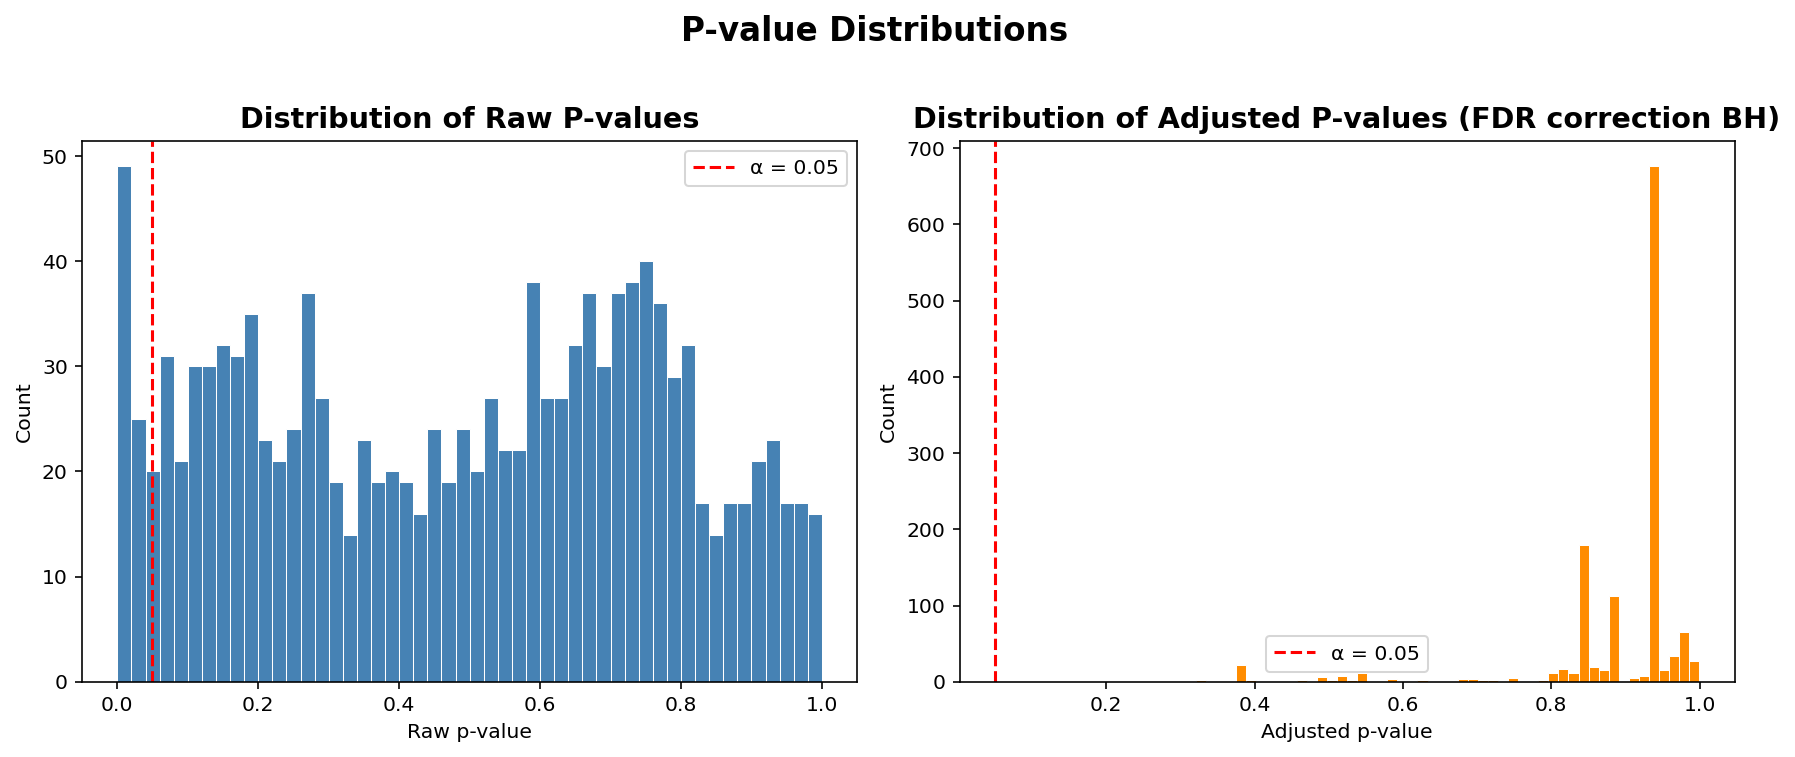

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw p-values
axes[0].hist(
    ancova["pvalue"].dropna(),
    bins=50,
    color="steelblue",
    edgecolor="white",
    linewidth=0.5,
)
axes[0].set_title("Distribution of Raw P-values", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Raw p-value")
axes[0].set_ylabel("Count")
axes[0].axvline(x=0.05, color="red", linestyle="--", linewidth=1.5, label="α = 0.05")
axes[0].legend()

# Adjusted p-values
axes[1].hist(
    ancova["padj"].dropna(),
    bins=50,
    color="darkorange",
    edgecolor="white",
    linewidth=0.5,
)
axes[1].set_title(
    "Distribution of Adjusted P-values (FDR correction BH)",
    fontsize=14,
    fontweight="bold",
)
axes[1].set_xlabel("Adjusted p-value")
axes[1].set_ylabel("Count")
axes[1].axvline(x=0.05, color="red", linestyle="--", linewidth=1.5, label="α = 0.05")
axes[1].legend()


plt.suptitle("P-value Distributions", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In the above plot, we are looking at our pvalues and adjusted pvalues in more detail.

We can also see how many features survived each threshold in the calculations below.

In [105]:
print("Raw p < 0.05:", (ancova["pvalue"] < 0.05).sum())
print("Raw p < 0.01:", (ancova["pvalue"] < 0.01).sum())
print("padj < 0.05: ", (ancova["padj"] < 0.05).sum())
print("padj < 0.1:  ", (ancova["padj"] < 0.1).sum())

Raw p < 0.05: 85
Raw p < 0.01: 29
padj < 0.05:  0
padj < 0.1:   0


## Identify hits

Finally, we can identify our best hits to then be analysed further. Once we have found
our top hits, we can match the (for now unknown) features with library spectra and
identify which metabolites they are. Then, we can carry out further analyses such as
enrichment analysis.

We can choose some thresholds for this, often we would choose an adjusted pvalue of 0.05 or lower, and an absolute log2 fold change of 1 or higher. 

In [107]:
# Primary hit list for follow-up
hits = ancova[(ancova["padj"] < 0.05) & (ancova["log2FC"].abs() > 1)]
print(f"Candidate metabolites: {len(hits)}")
print(f"Upregulated in CVD: {(hits['log2FC'] > 0).sum()}")
print(f"Downregulated in CVD: {(hits['log2FC'] < 0).sum()}")

Candidate metabolites: 0
Upregulated in CVD: 0
Downregulated in CVD: 0


We can save and export our hits to a csv file. Usually we would save the top hits and explore them further, but in this case, we will save the whole ancova, and just look further into the top metabolites here, although they are not significant.

In [54]:
ancova.to_csv("results_prepared/ancova_results.csv")

Done!